# All DC4 sources: source-specific light-curve responses

Build full-observation and NGC 4151 GTI catalogs for all 71 simulation files,
including extended sources. Compare native FITS counts against both an ordinary
response and a source/component-specific light-curve-weighted response.

The saved amplitudes are time averages: `K_yaml = K_injected * mean(L)`.
For each variable component, the response uses `L(t) / mean(L)` as its exposure
weight. Their product is `K_injected * L(t)`: the duration factor is applied
**once, not twice**. These YAML files therefore require the accompanying
response recipe; loading them with an ordinary response loses the time/attitude
correlation. This notebook does not modify any spectral-fitting notebook.

Normalization conventions are explicit. Periodic and short burst profiles use
unit-mean normalization over their native support. Mission-grid profiles use
the existing parallel-simulation recipe (1000 chunks by default). The CO nova
continuum's 500-chunk setting is inherited from the earlier diagnostic notebook
and is **inferred, not confirmed by archived simulation configuration**.
The recipe can be overridden per source; FITS counts never set a normalization.

Full and GTI extended-response cubes are processed sequentially. Steady extended
sources retain their ordinary extended response. A variable extended source
raises an explicit error until a time-dependent extended response is supplied.
The available attitude cadence is 15 seconds; exact light-curve integration
within those intervals does not provide sub-15-second attitude information.
All folded spectra use the existing unpolarized approximation.


In [1]:
from array import array
from functools import lru_cache
from copy import deepcopy
import gc
import json
import hashlib
import sys
import gzip
from pathlib import Path
import re

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astromodels import (
    Asymm_Gaussian_on_sphere,
    Band,
    Constant,
    Cutoff_powerlaw,
    ExtendedSource,
    Gaussian,
    Gaussian_on_sphere,
    Line,
    LinearPolarization,
    Log_parabola,
    Model,
    PointSource,
    Powerlaw,
    SpectralComponent,
    load_model,
)
from histpy import Axis, Axes, HealpixAxis, Histogram

from cosipy.data_io import BinnedData, EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLExtendedSourceResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
    ExtendedSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml.custom_functions import GalpropHealpixModel, SpecFromDat

%matplotlib inline

21:29:15 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=475902;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=867603;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=831847;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=98753;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

21:29:16 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=194735;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=141660;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

21:29:16 INFO      Starting 3ML!                                                                     ]8;id=25771;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=246416;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=119709;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=442034;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=665747;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=920175;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=87447;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=434095;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=72923;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=493955;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=184862;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=480400;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=144698;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=529246;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Locate the injected spectral tables

The tables are read directly from the local `cositools/cosi-sim` clone at `/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library`. The helper searches recursively below its `DC3/` and `DC4/` directories.

The catalog uses the following injected tables where a regular astromodels function is not a faithful representation:

- `cygX1_hard_0.1-0.4_spec.dat`
- `cygX1_hard_0.4-10_spec.dat`
- `GRS1758_spec.dat`
- `Crab_Ne_spec.dat`, `Crab_P1_spec.dat`, `Crab_Brg_spec.dat`, and `Crab_P2_spec.dat`
- `4C71p07_spectrum.dat`
- `4C_21_spectrum_noflare.dat` and `4C_21_spectrum_flare.dat`
- `MAXIJ1820_0.1-0.4_spec.dat` and `MAXIJ1820_0.4-10_spec.dat`
- `MAXIJ1348_0.1-0.4_spec.dat` and `MAXIJ1348_0.4-10_spec.dat`
- `3C454p3_low_spectrum.dat` and `3C454p3_high_spectrum.dat`
- `cygX3_transition_spec.dat`, `PSRB1259_spec.dat`, `LS5039_spec.dat`, and `J1846_spec.dat`
- `nova_co_continuum_spec.dat`

The individual simulated FITS source files in `DC4_Files/DC4_Sources` are event-data products and cannot replace these spectral `.dat` files.

In [2]:
SOURCE_DATA_ROOT = Path(
    "/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library"
)


def find_source_file(challenge, filename):
    """Find one source-library file below DC3/ or DC4/."""
    search_root = SOURCE_DATA_ROOT / challenge
    matches = sorted(search_root.rglob(filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename!r} below {search_root}. "
            "The simulated FITS source files are not spectral tables; copy the "
            "corresponding .dat file from the cosi-sim source library into this "
            "DC3/DC4 directory."
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Found more than one copy of {filename!r}: {matches}. "
            "Keep one copy or set the desired path explicitly."
        )

    return matches[0].resolve()


cygx1_low_path = find_source_file("DC3", "cygX1_hard_0.1-0.4_spec.dat")
cygx1_high_path = find_source_file("DC3", "cygX1_hard_0.4-10_spec.dat")
grs1758_path = find_source_file("DC3", "GRS1758_spec.dat")
crab_nebula_path = find_source_file("DC4", "Crab_Ne_spec.dat")
crab_p1_path = find_source_file("DC4", "Crab_P1_spec.dat")
crab_bridge_path = find_source_file("DC4", "Crab_Brg_spec.dat")
crab_p2_path = find_source_file("DC4", "Crab_P2_spec.dat")
four_c_71p07_path = find_source_file("DC4", "4C71p07_spectrum.dat")
four_c_21p35_noflare_path = find_source_file(
    "DC3", "4C_21_spectrum_noflare.dat"
)
four_c_21p35_flare_path = find_source_file(
    "DC3", "4C_21_spectrum_flare.dat"
)
maxi_j1820_low_path = find_source_file("DC3", "MAXIJ1820_0.1-0.4_spec.dat")
maxi_j1820_high_path = find_source_file("DC3", "MAXIJ1820_0.4-10_spec.dat")
maxi_j1348_low_path = find_source_file("DC3", "MAXIJ1348_0.1-0.4_spec.dat")
maxi_j1348_high_path = find_source_file("DC3", "MAXIJ1348_0.4-10_spec.dat")
three_c_454p3_low_path = find_source_file("DC4", "3C454p3_low_spectrum.dat")
three_c_454p3_high_path = find_source_file("DC4", "3C454p3_high_spectrum.dat")
cyg_x3_path = find_source_file("DC4", "cygX3_transition_spec.dat")
psr_b1259_path = find_source_file("DC3", "PSRB1259_spec.dat")
ls_5039_path = find_source_file("DC3", "LS5039_spec.dat")
psr_j1846_path = find_source_file("DC3", "J1846_spec.dat")
co_nova_continuum_path = find_source_file("DC3", "nova_co_continuum_spec.dat")

print("Cyg X-1 low-energy table:", cygx1_low_path)
print("Cyg X-1 high-energy table:", cygx1_high_path)
print("GRS 1758 table:", grs1758_path)
print("Crab tables:", crab_nebula_path, crab_p1_path, crab_bridge_path, crab_p2_path)
print("4C 71.07 table:", four_c_71p07_path)
print("4C 21.35 tables:", four_c_21p35_noflare_path, four_c_21p35_flare_path)
print("MAXI J1820 tables:", maxi_j1820_low_path, maxi_j1820_high_path)
print("MAXI J1348 tables:", maxi_j1348_low_path, maxi_j1348_high_path)
print("3C 454.3 tables:", three_c_454p3_low_path, three_c_454p3_high_path)
print("Cyg X-3 table:", cyg_x3_path)
print("PSR B1259 table:", psr_b1259_path)
print("LS 5039 table:", ls_5039_path)
print("PSR J1846 table:", psr_j1846_path)
print("CO nova continuum table:", co_nova_continuum_path)

Cyg X-1 low-energy table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1_hard_0.1-0.4_spec.dat
Cyg X-1 high-energy table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1_hard_0.4-10_spec.dat
GRS 1758 table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/GRS1758/GRS1758_spec.dat
Crab tables: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Ne_spec.dat /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_P1_spec.dat /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Brg_spec.dat /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_P2_spec.dat
4C 71.07 table: /Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Extragalactic/4C71p07/4C71p07_spectrum.dat
4C 21.35 tables: /Users/parshadkp/Sof

## Table-spectrum helper

`SpecFromDat` preserves the tabulated shape and provides a normalization parameter. Its current normalization uses a simple bin-width sum, so the helper below performs a numerical correction such that the model integral from 100 keV to 10 MeV equals the injected source-file flux. Absolute paths are stored in the YAML so the model can be reloaded from another working directory. The normalization is fixed before serialization.

In [3]:
ENERGY_MIN = 100.0
ENERGY_MAX = 10_000.0
PHOTON_FLUX_UNIT = 1 / (u.cm**2 * u.s)
DIFFERENTIAL_FLUX_UNIT = 1 / (u.keV * u.cm**2 * u.s)


def table_spectrum(dat_path, injected_photon_flux):
    """Create a SpecFromDat component normalized to an integrated flux."""
    spectrum = SpecFromDat(
        K=float(injected_photon_flux),
        dat=Path(dat_path).resolve(),
    )

    energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
    current_integral = np.trapezoid(spectrum(energy), energy)

    if not np.isfinite(current_integral) or current_integral <= 0:
        raise ValueError(f"Invalid spectrum integral for {dat_path}: {current_integral}")

    spectrum.K.value *= float(injected_photon_flux) / current_integral
    return spectrum


def normalize_analytic_components(components, injected_photon_flux):
    """Scale analytic component amplitudes to the injected integrated flux."""
    energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
    current_integral = np.trapezoid(
        sum(component(energy) for component in components),
        energy,
    )

    if not np.isfinite(current_integral) or current_integral <= 0:
        raise ValueError(f"Invalid analytic spectrum integral: {current_integral}")

    scale = float(injected_photon_flux) / current_integral
    for component in components:
        component.K.value *= scale


def set_normalization_step(parameter):
    """Use a scale-appropriate initial optimizer step."""
    parameter.delta = max(abs(parameter.value) * 0.05, 1e-12)

## 1. Cyg X-1 hard state

The injected hard-state spectrum is an `eqpair` calculation divided into two energy ranges for the polarization simulation. Native astromodels does not provide this `eqpair` model, so the two injected tables are retained and their relative normalization is fixed.

In [4]:
cygx1_low_flux = 0.04243172227636306
cygx1_high_flux = 0.003371822180706115

cygx1_low = table_spectrum(cygx1_low_path, cygx1_low_flux)
cygx1_high = table_spectrum(cygx1_high_path, cygx1_high_flux)
cygx1_spectrum = cygx1_low + cygx1_high

cygx1 = PointSource(
    "cyg_x1_hard",
    l=71.33496,
    b=3.066917,
    spectral_shape=cygx1_spectrum,
)

## 2. Crab

The DC4 Crab is retained as four distinct astromodels spectral components:
nebula, peak 1, bridge, and peak 2. Each uses its exact injected table and
integrated flux. The nebula has 40% polarization at 160° and the three pulsar
components have 20% polarization at 145°, in Galactic/IAU coordinates.

The pulsar light curves repeat every 0.0333924123 s and are normalized to unit
mean by MEGAlib. Each 15 s spacecraft interval therefore averages over about
449 pulse periods, so the time-integrated response uses their mean spectra.
The catalog preserves the injected polarization metadata, but exact
polarized folding additionally requires a detector response with a `Pol` axis.
The current continuum response lacks that axis, so the fitting notebook reports
and uses an in-memory zero-polarization approximation.

Although `Crab.source` contains `EarthOccultation false`, transferring that flag
to the current binned response overpredicts the selected Crab counts by almost
an order of magnitude. The spectral fit therefore retains the response's
standard source-visibility treatment, which agrees with the selected DC4 Crab
events.


In [5]:
crab_nebula = table_spectrum(crab_nebula_path, 0.033197515)
crab_p1 = table_spectrum(crab_p1_path, 0.002380673782066656)
crab_bridge = table_spectrum(crab_bridge_path, 0.0006280494007254569)
crab_p2 = table_spectrum(crab_p2_path, 0.0032012384701172636)

crab_components = [
    SpectralComponent(
        "nebula",
        crab_nebula,
        LinearPolarization(40.0, 160.0),
    ),
    SpectralComponent(
        "peak1",
        crab_p1,
        LinearPolarization(20.0, 145.0),
    ),
    SpectralComponent(
        "bridge",
        crab_bridge,
        LinearPolarization(20.0, 145.0),
    ),
    SpectralComponent(
        "peak2",
        crab_p2,
        LinearPolarization(20.0, 145.0),
    ),
]

crab = PointSource(
    "crab",
    l=184.5575,
    b=-5.78434,
    components=crab_components,
)

for component in crab.components.values():
    component.polarization.degree.fix = True
    component.polarization.angle.fix = True


## 3. 1E 1740.7−2942

Use the injected spectral table and photon flux from its `.source` definition.

In [6]:
definition = find_source_file("DC3", "1E1740_compow.source")
properties = {}
for raw_line in definition.read_text().splitlines():
    fields = raw_line.split("#", 1)[0].split()
    if fields and "." in fields[0]:
        properties[fields[0].split(".", 1)[1]] = fields[1:]
assert properties["Spectrum"][0].lower() == "file"
spectrum = table_spectrum(
    definition.parent / properties["Spectrum"][1], float(properties["Flux"][0]),
)
latitude, longitude = map(float, properties["Orientation"][-2:])
one_e_1740 = PointSource("one_e_1740_compow", l=longitude % 360.0, b=latitude, spectral_shape=spectrum)

## 4. GRS 1758−258

The injected spectrum is a thermal-Comptonization model. The original table is retained rather than replacing its curvature with a simple power law.

In [7]:
grs1758_flux = 0.003495
grs1758_spectrum = table_spectrum(grs1758_path, grs1758_flux)

grs1758 = PointSource(
    "grs_1758_258",
    l=4.50780,
    b=-1.36106,
    spectral_shape=grs1758_spectrum,
)

## 5. Cen A

Cen A is injected as a power law with photon index −1.732 and integrated 100 keV–10 MeV flux 0.00197 ph cm$^{-2}$ s$^{-1}$.

In [8]:
cena_spectrum = Powerlaw()
cena_spectrum.K.value = 2.227338148135328e-6
cena_spectrum.piv.value = 300.0
cena_spectrum.index.value = -1.732

cena_spectrum.K.unit = DIFFERENTIAL_FLUX_UNIT
cena_spectrum.piv.unit = u.keV
cena_spectrum.piv.fix = True
cena_spectrum.index.fix = True
cena = PointSource(
    "cena",
    l=309.516,
    b=19.417,
    spectral_shape=cena_spectrum,
)

## 6. 4C 71.07

4C 71.07 retains its injected tabulated spectrum and is treated as steady.

In [9]:
four_c_71p07_spectrum = table_spectrum(four_c_71p07_path, 0.00119)
four_c_71p07 = PointSource(
    "four_c_71p07",
    l=143.540759,
    b=34.425671,
    spectral_shape=four_c_71p07_spectrum,
)

## 7. 4C 21.35

The non-flare and flare spectra are separate variable catalog entries. Each uses its own temporal profile and weighted response. Its frozen amplitude includes the selected temporal mean; FITS counts are comparison data only.

In [10]:
four_c_21p35_noflare_spectrum = table_spectrum(
    four_c_21p35_noflare_path,
    0.0005535,
)
four_c_21p35_noflare = PointSource(
    "four_c_21p35_noflare",
    l=255.073637,
    b=81.659766,
    spectral_shape=four_c_21p35_noflare_spectrum,
)

four_c_21p35_flare_spectrum = table_spectrum(
    four_c_21p35_flare_path,
    0.017293201590129727,
)
four_c_21p35_flare = PointSource(
    "four_c_21p35_flare",
    l=255.073637,
    b=81.659766,
    spectral_shape=four_c_21p35_flare_spectrum,
)

## 8. MAXI J1820

The two injected tabulated components share one outburst light curve and one linked catalog amplitude.

In [11]:
maxi_j1820_low = table_spectrum(
    maxi_j1820_low_path,
    0.13820979415525897,
)
maxi_j1820_high = table_spectrum(
    maxi_j1820_high_path,
    0.005963517352694539,
)
maxi_j1820 = PointSource(
    "maxi_j1820",
    l=35.8535,
    b=10.15915,
    spectral_shape=maxi_j1820_low + maxi_j1820_high,
)

## 9. MAXI J1348−630

The two injected tabulated components share one outburst light curve and one linked catalog amplitude.

In [12]:
maxi_j1348_low = table_spectrum(
    maxi_j1348_low_path,
    0.08633295828868433,
)
maxi_j1348_high = table_spectrum(
    maxi_j1348_high_path,
    0.0023113717669982913,
)
maxi_j1348 = PointSource(
    "maxi_j1348",
    l=309.26389732,
    b=-1.10328,
    spectral_shape=maxi_j1348_low + maxi_j1348_high,
)

## 10. 3C 454.3

The low and high states are separate variable catalog entries, with independent temporal factors and light-curve-weighted responses for each selection.

In [13]:
three_c_454p3_low = PointSource(
    "three_c_454p3_low",
    l=86.111069,
    b=-38.183817,
    spectral_shape=table_spectrum(three_c_454p3_low_path, 0.00029),
)
three_c_454p3_high = PointSource(
    "three_c_454p3_high",
    l=86.111069,
    b=-38.183817,
    spectral_shape=table_spectrum(three_c_454p3_high_path, 0.00624),
)

## 11. NGC 1068

Use the injected spectral table and photon flux from its `.source` definition.

In [14]:
definition = find_source_file("DC4", "NGC_1068.source")
properties = {}
for raw_line in definition.read_text().splitlines():
    fields = raw_line.split("#", 1)[0].split()
    if fields and "." in fields[0]:
        properties[fields[0].split(".", 1)[1]] = fields[1:]
assert properties["Spectrum"][0].lower() == "file"
spectrum = table_spectrum(
    definition.parent / properties["Spectrum"][1], float(properties["Flux"][0]),
)
latitude, longitude = map(float, properties["Orientation"][-2:])
ngc1068 = PointSource("ngc1068", l=longitude % 360.0, b=latitude, spectral_shape=spectrum)

## 12. NGC 4151

This is the updated mock-data injection from `AGN_Corona_DC4.ipynb`: a cutoff power law with `K = 0.15` at 1 keV, index −1.75, and cutoff 200 keV, plus an index −3.8 power-law tail whose differential flux at 200 keV is 30% of the thermal flux. The implementation is pivoted at 200 keV without changing the injected spectrum.

In [15]:
ngc4151_thermal = Cutoff_powerlaw()
ngc4151_thermal.K.value = 0.15 * 200.0**-1.75
ngc4151_thermal.piv.value = 200.0
ngc4151_thermal.index.value = -1.75
ngc4151_thermal.xc.value = 200.0
ngc4151_tail = Powerlaw()
ngc4151_tail_fraction_at_200kev = 0.30
ngc4151_tail.K.value = (
    ngc4151_tail_fraction_at_200kev
    * ngc4151_thermal.evaluate_at(200.0)
)
ngc4151_tail.piv.value = 200.0
ngc4151_tail.index.value = -3.8

for component in (ngc4151_thermal, ngc4151_tail):
    component.K.unit = DIFFERENTIAL_FLUX_UNIT
    component.piv.unit = u.keV
    component.piv.fix = True
    component.index.fix = True

ngc4151_thermal.xc.unit = u.keV
ngc4151_thermal.xc.fix = True
assert np.isclose(
    ngc4151_tail.evaluate_at(200.0)
    / ngc4151_thermal.evaluate_at(200.0),
    ngc4151_tail_fraction_at_200kev,
)

ngc4151_energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
ngc4151_injected_flux = np.trapezoid(
    (ngc4151_thermal + ngc4151_tail)(ngc4151_energy),
    ngc4151_energy,
)
assert np.isclose(ngc4151_injected_flux, 0.0025171894, rtol=1e-5)

ngc4151 = PointSource(
    "ngc4151",
    l=155.077404,
    b=75.063170,
    spectral_shape=ngc4151_thermal + ngc4151_tail,
)

## 13. Cyg X-3

The injected transition-state spectrum is retained as a tabulated model.

In [16]:
cyg_x3 = PointSource(
    "cyg_x3",
    l=79.84549,
    b=0.70006,
    spectral_shape=table_spectrum(cyg_x3_path, 0.001331405),
)

## 14. PSR B1259−63

The injected table defines the spectral shape. The selected temporal mean sets its frozen normalization, and the response includes its temporal profile. FITS counts are not fitted.

In [17]:
psr_b1259 = PointSource(
    "psr_b1259",
    l=304.18358257,
    b=-0.99158457,
    spectral_shape=table_spectrum(psr_b1259_path, 0.00061253),
)

## 15. 1RXS J170849.0−400901

Use the injected spectral table and photon flux from its `.source` definition.

In [18]:
definition = find_source_file("DC4", "1RXSJ170849.source")
properties = {}
for raw_line in definition.read_text().splitlines():
    fields = raw_line.split("#", 1)[0].split()
    if fields and "." in fields[0]:
        properties[fields[0].split(".", 1)[1]] = fields[1:]
assert properties["Spectrum"][0].lower() == "file"
spectrum = table_spectrum(
    definition.parent / properties["Spectrum"][1], float(properties["Flux"][0]),
)
latitude, longitude = map(float, properties["Orientation"][-2:])
one_rxs_j170849 = PointSource("one_rxs_j170849", l=longitude % 360.0, b=latitude, spectral_shape=spectrum)

## 16. Generic magnetar

Use the injected spectral table and photon flux from its `.source` definition.

In [19]:
definition = find_source_file("DC4", "magnetar2.source")
properties = {}
for raw_line in definition.read_text().splitlines():
    fields = raw_line.split("#", 1)[0].split()
    if fields and "." in fields[0]:
        properties[fields[0].split(".", 1)[1]] = fields[1:]
assert properties["Spectrum"][0].lower() == "file"
spectrum = table_spectrum(
    definition.parent / properties["Spectrum"][1], float(properties["Flux"][0]),
)
latitude, longitude = map(float, properties["Orientation"][-2:])
generic_magnetar = PointSource("generic_magnetar", l=longitude % 360.0, b=latitude, spectral_shape=spectrum)

## 17. LS 5039

The injected table defines the spectral shape. Its periodic light curve is integrated over the selected intervals and included in the response, with the temporal mean stored in the frozen amplitude.

In [20]:
ls_5039 = PointSource(
    "ls_5039",
    l=16.88158741,
    b=-1.28921165,
    spectral_shape=table_spectrum(ls_5039_path, 0.0003006),
)

## 18. PSR J1846−0258

The injected table defines the spectral shape. Its periodic light curve is integrated over the selected intervals and included in the response, with the temporal mean stored in the frozen amplitude.

In [21]:
psr_j1846 = PointSource(
    "psr_j1846",
    l=29.71195,
    b=-0.24012,
    spectral_shape=table_spectrum(psr_j1846_path, 0.000152392),
)

## 19. CO nova continuum

This entry is the continuum component; the two nova lines are added by the manifest parser below. The continuum uses the existing inferred 500-chunk normalization recipe and its own temporal response. No emission overlaps the NGC 4151 GTI, so its predicted GTI counts are zero.

In [22]:
co_nova_continuum = PointSource(
    "co_nova_continuum",
    l=310.9847,
    b=2.7256,
    spectral_shape=table_spectrum(co_nova_continuum_path, 0.122071),
)

## Parse the remaining DC4 MEGAlib source definitions

The helper below supports every beam/spectrum syntax used by the
included manifest: point sources, circular/asymmetric Gaussian sky
morphologies, Gaussian lines, Band, Comptonized, power-law and file
spectra, plus `FarFieldNormalizedEnergyBeamFluxFunction` maps.

The latter are genuinely energy-dependent spatial templates.  They are
converted once to the HEALPix FITS layout consumed by
`GalpropHealpixModel`; replacing them with a point source or a separable
one-dimensional `.dat` spectrum would lose their injected morphology.

In [23]:
SPATIAL_TEMPLATE_DIRECTORY = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/DC4_Sources/DC4_Spatial_Templates"
).resolve()
# Match the spatial-template grid to the cached extended-response grid.
# Build each MEGAlib map at higher resolution first, then area-average it
# onto NSIDE 8 so compact sources cannot fall between coarse pixel centers.
SPATIAL_TEMPLATE_NSIDE = 8
SPATIAL_TEMPLATE_OVERSAMPLE_NSIDE = 64
SPATIAL_TEMPLATE_FORMAT_TAG = "perMeV_v3"
OVERWRITE_SPATIAL_TEMPLATES = False


def safe_name(value):
    name = re.sub(r"[^A-Za-z0-9_]", "_", str(value)).strip("_").lower()
    if not name or name[0].isdigit():
        name = f"src_{name}"
    return name


def find_source_definition(challenge, source_stem):
    matches = sorted(
        (SOURCE_DATA_ROOT / challenge / "sources").rglob(
            f"{source_stem}.source"
        )
    )
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one {source_stem}.source below {challenge}; "
            f"found {matches}"
        )
    return matches[0].resolve()


def resolve_source_asset(source_definition, filename):
    path = source_definition.parent / filename
    candidates = [path, Path(f"{path}.gz")]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not resolve {filename!r} next to {source_definition}"
    )


def parse_megalib_blocks(source_definition):
    # Return one property dictionary per DataChallenge.Source block.
    blocks = []
    by_megalib_name = {}
    for raw_line in source_definition.read_text().splitlines():
        line = raw_line.split("#", 1)[0].strip()
        if not line:
            continue
        tokens = line.split()
        if tokens[:1] == ["DataChallenge.Source"]:
            megalib_name = tokens[1]
            block = {"_name": megalib_name}
            blocks.append(block)
            by_megalib_name[megalib_name] = block
            continue
        if "." not in tokens[0]:
            continue
        megalib_name, prop = tokens[0].split(".", 1)
        if megalib_name in by_megalib_name:
            by_megalib_name[megalib_name][prop] = tokens[1:]
    if not blocks:
        raise ValueError(f"No DataChallenge.Source blocks in {source_definition}")
    return blocks


def normalization_parameter(shape):
    candidates = [
        parameter
        for parameter in shape.parameters.values()
        if parameter.is_normalization
    ]
    if not candidates:
        # astromodels marks the Gaussian-line amplitude F as a prior
        # parameter rather than a source normalization.  It is still the
        # multiplicative integrated line flux for this use.
        candidates = [
            shape.parameters[name]
            for name in ("F", "K", "k")
            if name in shape.parameters
        ]
    if len(candidates) != 1:
        raise RuntimeError(
            f"Expected one normalization in {shape.name}; found {candidates}"
        )
    return candidates[0]


def normalize_shape_in_band(shape, photon_flux):
    energy = np.geomspace(ENERGY_MIN, ENERGY_MAX, 20_000)
    integral = float(np.trapezoid(shape(energy), energy))
    if not np.isfinite(integral) or integral <= 0:
        raise ValueError(f"Invalid integral {integral} for {shape}")
    normalization_parameter(shape).value *= float(photon_flux) / integral
    return shape


def make_parsed_spectrum(block, source_definition):
    tokens = block["Spectrum"]
    kind = tokens[0].lower()
    photon_flux = float(block["Flux"][0])

    if kind == "file":
        return table_spectrum(
            resolve_source_asset(source_definition, tokens[1]),
            photon_flux,
        )

    if kind == "gaussian":
        shape = Gaussian()
        shape.F.value = 1.0
        shape.mu.value = float(tokens[1])
        shape.sigma.value = float(tokens[2])
        return normalize_shape_in_band(shape, photon_flux)

    if kind == "band":
        shape = Band()
        shape.K.value = 1.0e-5
        shape.piv.value = 100.0
        shape.alpha.value = float(tokens[3])
        shape.beta.value = float(tokens[4])
        shape.xp.value = float(tokens[5])
        return normalize_shape_in_band(shape, photon_flux)

    if kind == "comptonized":
        alpha = float(tokens[3])
        epeak = float(tokens[4])
        shape = Cutoff_powerlaw()
        shape.K.value = 1.0e-5
        shape.piv.value = 100.0
        shape.index.value = alpha
        shape.xc.value = epeak / (2.0 + alpha)
        return normalize_shape_in_band(shape, photon_flux)

    if kind == "powerlaw":
        shape = Powerlaw()
        shape.K.value = 1.0e-5
        shape.piv.value = 100.0
        shape.index.value = -float(tokens[3])
        return normalize_shape_in_band(shape, photon_flux)

    raise NotImplementedError(
        f"Unsupported spectrum {block['Spectrum']} in {source_definition}"
    )


def make_polarization(block):
    tokens = block.get("Polarization")
    if tokens is None:
        return None
    # MEGAlib stores degree as a fraction; astromodels uses percent.
    polarization = LinearPolarization(
        100.0 * float(tokens[-2]),
        float(tokens[-1]),
    )
    polarization.degree.fix = True
    polarization.angle.fix = True
    return polarization

In [24]:
def read_normalized_energy_beam(path):
    # Read a MEGAlib 3D Functions PA/TA/EA/AP table.
    opener = gzip.open if Path(path).suffix == ".gz" else open
    pa = ta = ea = None
    entries = []
    with opener(path, "rt") as stream:
        for raw_line in stream:
            tokens = raw_line.split()
            if not tokens:
                continue
            if tokens[0] == "PA":
                pa = np.asarray(tokens[1:], dtype=float)
            elif tokens[0] == "TA":
                ta = np.asarray(tokens[1:], dtype=float)
            elif tokens[0] == "EA":
                ea = np.asarray(tokens[1:], dtype=float)
            elif tokens[0] == "AP":
                entries.append(
                    (
                        int(tokens[1]),
                        int(tokens[2]),
                        int(tokens[3]),
                        float(tokens[4]),
                    )
                )
    if pa is None or ta is None or ea is None:
        raise ValueError(f"Missing PA/TA/EA axes in {path}")
    values = np.zeros((pa.size, ta.size, ea.size), dtype=np.float32)
    for i_pa, i_ta, i_ea, value in entries:
        values[i_pa, i_ta, i_ea] = value
    return pa, ta, ea, values


def nearest_axis_indices(axis, values):
    order = np.argsort(axis)
    sorted_axis = axis[order]
    insertion = np.searchsorted(sorted_axis, values)
    insertion = np.clip(insertion, 1, sorted_axis.size - 1)
    left = sorted_axis[insertion - 1]
    right = sorted_axis[insertion]
    choose_right = np.abs(values - right) < np.abs(values - left)
    nearest = insertion - 1 + choose_right.astype(int)
    return order[nearest]


def megalib_map_to_galprop_fits(
    input_path,
    output_path,
    nside=SPATIAL_TEMPLATE_NSIDE,
    overwrite=OVERWRITE_SPATIAL_TEMPLATES,
):
    # Convert the injected coupled spatial/spectral table to HEALPix.
    output_path = Path(output_path).resolve()
    if output_path.exists() and not overwrite:
        return output_path

    pa, ta, energy_kev, values = read_normalized_energy_beam(input_path)
    sampling_nside = max(int(nside), int(SPATIAL_TEMPLATE_OVERSAMPLE_NSIDE))
    npix = hp.nside2npix(sampling_nside)
    longitude, latitude = hp.pix2ang(
        sampling_nside,
        np.arange(npix),
        lonlat=True,
    )
    longitude = ((longitude + 180.0) % 360.0) - 180.0
    theta = 90.0 - latitude
    i_pa = nearest_axis_indices(pa, longitude)
    i_ta = nearest_axis_indices(ta, theta)
    sampled_values = values[i_pa, i_ta, :]

    if sampling_nside == int(nside):
        healpix_values = sampled_values
    else:
        # The table stores intensity, so power=0 preserves the area-weighted
        # mean intensity and therefore the total flux after pixel-area folding.
        healpix_values = np.column_stack(
            [
                hp.ud_grade(
                    sampled_values[:, energy_index],
                    nside_out=int(nside),
                    order_in="RING",
                    order_out="RING",
                    power=0,
                )
                for energy_index in range(sampled_values.shape[1])
            ]
        ).astype(np.float32, copy=False)

    # GalpropHealpixModel interpolates at response-bin edges.  Add zero
    # anchors outside the simulated band to avoid extrapolated line tails.
    energy_mev = energy_kev / 1000.0
    # MEGAlib energies and differential intensities are per keV, whereas
    # GalpropHealpixModel expects energy in MeV and intensity per MeV.
    # Preserve flux under the coordinate change: f_MeV = 1000 * f_keV.
    healpix_values *= 1000.0
    if np.any(np.diff(energy_mev) <= 0.0):
        raise ValueError(f"Energy axis is not strictly increasing in {input_path}")
    epsilon = 1.0e-6
    lower_inner = energy_mev[0] * (1.0 - epsilon)
    upper_inner = energy_mev[-1] * (1.0 + epsilon)
    lower_outer = min(ENERGY_MIN / 1000.0, lower_inner)
    upper_outer = max(ENERGY_MAX / 1000.0, upper_inner)
    if lower_outer >= lower_inner:
        lower_outer = lower_inner * (1.0 - epsilon)
    if upper_outer <= upper_inner:
        upper_outer = upper_inner * (1.0 + epsilon)
    energy_mev = np.concatenate(
        ([lower_outer, lower_inner], energy_mev, [upper_inner, upper_outer])
    )
    zero_columns = np.zeros((healpix_values.shape[0], 2), dtype=np.float32)
    healpix_values = np.column_stack(
        (
            zero_columns,
            healpix_values,
            zero_columns,
        )
    )

    skymap_columns = [
        fits.Column(
            name=f"ENERGY{index:03d}",
            format="E",
            unit="ph cm-2 s-1 sr-1 MeV-1",
            array=healpix_values[:, index],
        )
        for index in range(energy_mev.size)
    ]
    skymap = fits.BinTableHDU.from_columns(
        skymap_columns,
        name="SKYMAP",
    )
    energies = fits.BinTableHDU.from_columns(
        [
            fits.Column(
                name="ENERGY",
                format="E",
                unit="MeV",
                array=energy_mev,
            )
        ],
        name="ENERGIES",
    )
    skymap.header["NSIDE"] = nside
    skymap.header["ORDERING"] = "RING"
    skymap.header["COORDSYS"] = "GAL"
    skymap.header["MAPVERS"] = SPATIAL_TEMPLATE_FORMAT_TAG
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fits.HDUList([fits.PrimaryHDU(), skymap, energies]).writeto(
        output_path,
        overwrite=overwrite,
    )
    return output_path


def make_map_source(unit_key, block, source_definition):
    map_path = resolve_source_asset(source_definition, block["Beam"][1])
    template_path = megalib_map_to_galprop_fits(
        map_path,
        SPATIAL_TEMPLATE_DIRECTORY
        / (
            f"{unit_key}_nside{SPATIAL_TEMPLATE_NSIDE}_"
            f"{SPATIAL_TEMPLATE_FORMAT_TAG}.fits"
        ),
    )
    spatial = GalpropHealpixModel()
    # Defer loading large templates until the response is folded.
    spatial._fitsfile = str(template_path)
    spatial._file_loaded = False
    spatial.K.value = 1.0
    # A 3D astromodels spatial template automatically receives the fixed
    # spectrum.main.Constant placeholder required by COSI folding.
    return ExtendedSource(unit_key, spatial_shape=spatial)

In [25]:
def parse_megalib_source(unit_key, source_definition):
    # Build one astromodels source from one manifest simulation file.
    blocks = parse_megalib_blocks(source_definition)
    beam_kinds = {block["Beam"][0] for block in blocks}
    if beam_kinds == {"FarFieldNormalizedEnergyBeamFluxFunction"}:
        if len(blocks) != 1:
            raise ValueError(
                f"Expected one coupled map in {source_definition}; got {len(blocks)}"
            )
        return make_map_source(unit_key, blocks[0], source_definition)

    group_keys = []
    groups = {}
    for block in blocks:
        orientation = tuple(block["Orientation"][-2:])
        beam = tuple(block["Beam"])
        group_key = (beam, orientation)
        if group_key not in groups:
            groups[group_key] = []
            group_keys.append(group_key)
        groups[group_key].append(block)
    if len(groups) != 1:
        raise ValueError(
            f"{source_definition} contains multiple positions/morphologies. "
            "Add an explicit grouping rule before catalog generation."
        )

    (beam, orientation), grouped_blocks = next(iter(groups.items()))
    latitude, longitude = map(float, orientation)
    longitude %= 360.0
    component_names = []
    used_component_names = set()
    spectral_shapes = []
    polarizations = []
    for index, block in enumerate(grouped_blocks, start=1):
        component_name = safe_name(block["_name"])
        if component_name in used_component_names:
            component_name = f"{component_name}_{index}"
        used_component_names.add(component_name)
        component_names.append(component_name)
        spectral_shapes.append(make_parsed_spectrum(block, source_definition))
        polarizations.append(make_polarization(block))

    if beam[0] == "FarFieldPointSource":
        components = [
            SpectralComponent(name, shape, polarization)
            for name, shape, polarization in zip(
                component_names, spectral_shapes, polarizations
            )
        ]
        return PointSource(
            unit_key,
            l=longitude,
            b=latitude,
            components=components,
        )

    if beam[0] == "FarFieldGaussian":
        spatial = Gaussian_on_sphere(
            lon0=longitude,
            lat0=latitude,
            sigma=float(beam[-1]),
        )
    elif beam[0] == "FarFieldAssymetricGaussian":
        axis_a = float(beam[3])
        axis_b = float(beam[4])
        major = max(axis_a, axis_b)
        minor = min(axis_a, axis_b)
        eccentricity = np.sqrt(max(0.0, 1.0 - (minor / major) ** 2))
        spatial = Asymm_Gaussian_on_sphere(
            lon0=longitude,
            lat0=latitude,
            a=major,
            e=eccentricity,
            theta=float(beam[5]),
        )
    else:
        raise NotImplementedError(
            f"Unsupported beam {beam} in {source_definition}"
        )

    # BinnedThreeMLExtendedSourceResponse folds spectrum.main. Collapse
    # co-spatial line/continuum components into one composite spectral shape
    # so every analytic extended source has that standard component path.
    polarization_signatures = [
        None if polarization is None else polarization.to_dict()
        for polarization in polarizations
    ]
    if any(
        signature != polarization_signatures[0]
        for signature in polarization_signatures[1:]
    ):
        raise ValueError(
            f"{source_definition} has co-spatial components with different "
            "polarizations, which cannot be collapsed into one extended source"
        )
    spectral_shape = spectral_shapes[0]
    for component_shape in spectral_shapes[1:]:
        spectral_shape = spectral_shape + component_shape
    return ExtendedSource(
        unit_key,
        spatial_shape=spatial,
        spectral_shape=spectral_shape,
        polarization=polarizations[0],
    )

## Complete DC4 simulation-file manifest

In [26]:
# The first 21 entries use the reviewed continuum models defined above.
BASE_SIMULATION_UNITS = [
    ("cyg_x1_hard", cygx1, "DC3", "cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("crab", crab, "DC4", "Crab_DC4_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("one_e_1740_compow", one_e_1740, "DC3", "1E1740_compow_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grs_1758_258", grs1758, "DC3", "GRS1758_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("cena", cena, "DC4", "CenA_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("four_c_71p07", four_c_71p07, "DC4", "4C71p07_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("four_c_21p35_noflare", four_c_21p35_noflare, "DC3", "4C21p35_noflare_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("four_c_21p35_flare", four_c_21p35_flare, "DC3", "4C21p35_flare_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("maxi_j1820", maxi_j1820, "DC3", "MAXIJ1820_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("maxi_j1348", maxi_j1348, "DC3", "MAXIJ1348_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("three_c_454p3_low", three_c_454p3_low, "DC4", "3C454p3_low_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("three_c_454p3_high", three_c_454p3_high, "DC4", "3C454p3_high_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("ngc1068", ngc1068, "DC4", "NGC_1068_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("ngc4151", ngc4151, "DC4", "NGC_4151_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("cyg_x3", cyg_x3, "DC4", "cygX3_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("psr_b1259", psr_b1259, "DC3", "PSRB1259_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("one_rxs_j170849", one_rxs_j170849, "DC4", "1RXSJ170849_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("generic_magnetar", generic_magnetar, "DC4", "magnetar2_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("ls_5039", ls_5039, "DC3", "LS5039_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("psr_j1846", psr_j1846, "DC3", "PSRJ1846_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("co_nova_continuum", co_nova_continuum, "DC3", "nova_co_continuum_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
]

# key, source-library challenge, .source stem, event-file challenge, event filename
PARSED_SIMULATION_UNITS = [
    ("tuc_47", "DC3", "Globular_Cluster_Tuc_47", "DC3", "Globular_Cluster_Tuc_47_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("omega_cen", "DC3", "Globular_Cluster_Omega_Cen", "DC3", "Globular_Cluster_Omega_Cen_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("ngc_6397", "DC3", "Globular_Cluster_NGC_6397", "DC3", "Globular_Cluster_NGC_6397_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("ngc_6121", "DC3", "Globular_Cluster_NGC_6121", "DC3", "Globular_Cluster_NGC_6121_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_26al_line", "DC3", "Positrons_from_26Al_line", "DC3", "Positrons_from_26Al_line_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_26al_cont", "DC3", "Positrons_from_26Al_cont", "DC3", "Positrons_from_26Al_cont_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_44ti_line", "DC3", "Positrons_from_44Ti_line", "DC3", "Positrons_from_44Ti_line_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_44ti_cont", "DC3", "Positrons_from_44Ti_cont", "DC3", "Positrons_from_44Ti_cont_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("narrow_bulge_511", "DC3", "NB_511", "DC3", "Narrow_Bulge_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("broad_bulge_511", "DC3", "BB_511", "DC3", "Broad_Bulge_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("vela_snr_511", "DC3", "Vela_SNR_511", "DC3", "Vela_SNR_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("co_nova_511kev", "DC3", "nova_co_511keV", "DC3", "nova_co_511keV_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("co_nova_478kev", "DC3", "nova_co_478keV", "DC3", "nova_co_478keV_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("al26_cyg_region", "DC3", "26Al_Cyg_Region", "DC3", "26Al_Cyg_Region_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("al26_ne2001", "DC3", "26Al_NE2001", "DC3", "26Al_NE2001_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("fe60_cyg_region", "DC3", "60Fe_Cyg_Region", "DC3", "60Fe_Cyg_Region_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("fe60_ne2001", "DC3", "60Fe_NE2001", "DC3", "60Fe_NE2001_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn081207680", "DC3", "bn081207680", "DC3", "GRB_bn081207680_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn090424592", "DC3", "bn090424592", "DC3", "GRB_bn090424592_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn100612726", "DC3", "bn100612726", "DC3", "GRB_bn100612726_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn110605183", "DC3", "bn110605183", "DC3", "GRB_bn110605183_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn131122490", "DC3", "bn131122490", "DC3", "GRB_bn131122490_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn140329295", "DC3", "bn140329295", "DC3", "GRB_bn140329295_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn161004964", "DC3", "bn161004964", "DC3", "GRB_bn161004964_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn170405777", "DC3", "bn170405777", "DC3", "GRB_bn170405777_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn180504136", "DC3", "bn180504136", "DC3", "GRB_bn180504136_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn180703876", "DC3", "bn180703876", "DC3", "GRB_bn180703876_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("grb_bn080802386_flux150", "DC3", "bn080802386", "DC3", "GRB_bn080802386_flux150_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgf_051103", "DC3", "MGF051103", "DC3", "GRB_MGF051103_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgf_070201", "DC3", "MGF070201", "DC3", "GRB_MGF070201_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgf_070222", "DC3", "MGF070222", "DC3", "GRB_MGF070222_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgf_180128a", "DC3", "MGF180128A", "DC3", "GRB_MGF180128A_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgf_200415a", "DC3", "MGF200415A", "DC3", "GRB_MGF200415A_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgf_231115a", "DC3", "MGF231115A", "DC3", "GRB_MGF231115A_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("casa_g16_distribution", "DC4", "CasAG16distribution", "DC4", "CasAG16distribution_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("g1903", "DC4", "G1903", "DC4", "GS1903_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("kepler", "DC4", "Kepler", "DC4", "Kepler_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("mgt_burst_bright_complex", "DC3", "MgtBurst_bright_complex", "DC4", "MgtBurst_bright_complex_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("orion_eridanus", "DC4", "OrEr", "DC4", "OrEr_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positron_annihilation_in_flight", "DC4", "Positrons_In_Flight_Annihilation", "DC4", "positron_annihilation_in_flight_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_central_source", "DC4", "Positrons_Central_Source", "DC4", "Positrons_Central_Source_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_thin_disk_cont", "DC4", "Positrons_Thin_Disk_cont", "DC4", "positrons_thin_disk_cont_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("positrons_thin_disk_line", "DC4", "Positrons_Thin_Disk_line", "DC4", "positrons_thin_disk_line_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("sn1987a", "DC4", "SN1987A", "DC4", "SN1987A_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("tycho", "DC4", "Tycho", "DC4", "Tycho_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("upper_scorpius", "DC4", "USco", "DC4", "USco_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("vela_jr_44ti", "DC4", "VelaJr_44Ti", "DC4", "VelaJr_44Ti_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("lmc_511", "DC3", "LMC_Gaussian_511", "DC4", "LMC_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("m31_511", "DC3", "M31_Gaussian_511", "DC4", "M31_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
    ("virgo_511", "DC3", "Virgo_Gaussian_511", "DC4", "Virgo_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"),
]

assert len(BASE_SIMULATION_UNITS) == 21
assert len(PARSED_SIMULATION_UNITS) == 50
assert len(BASE_SIMULATION_UNITS) + len(PARSED_SIMULATION_UNITS) == 71

In [27]:
DC4_ROOT_CANDIDATES = [
    Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files"),
    Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files"),
]
DC4_FILES_ROOT = next(
    (candidate for candidate in DC4_ROOT_CANDIDATES if candidate.exists()),
    None,
)
if DC4_FILES_ROOT is None:
    raise FileNotFoundError(f"Could not find DC4_Files: {DC4_ROOT_CANDIDATES}")
SOURCE_EVENT_ROOT = DC4_FILES_ROOT / "DC4_Sources"

simulation_units = {}
for key, source, event_challenge, event_filename in BASE_SIMULATION_UNITS:
    simulation_units[key] = {
        "source": source,
        "source_definition": "reviewed continuum model",
        "event_file": SOURCE_EVENT_ROOT / event_challenge / event_filename,
    }

for key, model_challenge, source_stem, event_challenge, event_filename in PARSED_SIMULATION_UNITS:
    source_definition = find_source_definition(model_challenge, source_stem)
    simulation_units[key] = {
        "source": parse_megalib_source(key, source_definition),
        "source_definition": str(source_definition),
        "event_file": SOURCE_EVENT_ROOT / event_challenge / event_filename,
    }

if len(simulation_units) != 71:
    raise RuntimeError(f"Expected 71 manifest files, got {len(simulation_units)}")
missing_events = [str(unit["event_file"]) for unit in simulation_units.values() if not unit["event_file"].exists()]
if missing_events:
    raise FileNotFoundError("Missing native FITS inputs before response loading:\n" + "\n".join(missing_events))

seed_model = Model(*(unit["source"] for unit in simulation_units.values()))
source_types = pd.Series(
    {
        key: type(unit["source"]).__name__
        for key, unit in simulation_units.items()
    },
    name="astromodels type",
)
print("DC4 manifest simulation files:", len(simulation_units))
print("Catalog source entries:", len(seed_model.sources))
display(source_types.value_counts().rename("entries").to_frame())

DC4 manifest simulation files: 71
Catalog source entries: 71


,entries
astromodels type,
PointSource,52
ExtendedSource,19


## Select full and GTI time intervals

In [28]:
AGN_BINNING_CONFIG = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN/agn.yaml"
)
ORIENTATION_PATH = DC4_FILES_ROOT / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
RESPONSE_PATH = DC4_FILES_ROOT / (
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)

GTI_TARGET_NAME = "NGC4151"
GTI_MAX_OFFAXIS = 60.0 * u.deg
GTI_EARTH_OCCULTATION = True
LOAD_EXISTING_BINNED_FILES = True
SAVE_BINNED_GTI_FILES = True
OVERWRITE_BINNED_GTI_FILES = False
BINNED_GTI_DIRECTORY = (
    SOURCE_EVENT_ROOT / "DC4_Binned" / f"{GTI_TARGET_NAME}_Cut"
)
NGC4151_READ_ONLY_BINNED_FILE = BINNED_GTI_DIRECTORY / (
    "NGC_4151_ec200_0p30_DC4_COSI_cpl_pl_time_cut_in_fov.hdf5"
)

EXTENDED_RESPONSE_NSIDE = 8
if SPATIAL_TEMPLATE_NSIDE != EXTENDED_RESPONSE_NSIDE:
    raise ValueError(
        "Spatial templates must be area-averaged onto the extended-response NSIDE."
    )
LOAD_EXISTING_EXTENDED_RESPONSES = True
OVERWRITE_EXTENDED_RESPONSES = False
EXTENDED_RESPONSE_DIRECTORY = DC4_FILES_ROOT / "Extended_Responses" / "NGC4151_Cut"
FULL_EXTENDED_RESPONSE_PATH = EXTENDED_RESPONSE_DIRECTORY / (
    f"DC4_continuum_full_extended_response_nside{EXTENDED_RESPONSE_NSIDE}.h5"
)
GTI_EXTENDED_RESPONSE_PATH = EXTENDED_RESPONSE_DIRECTORY / (
    f"DC4_continuum_NGC4151_60deg_GTI_extended_response_nside{EXTENDED_RESPONSE_NSIDE}.h5"
)

for path in (AGN_BINNING_CONFIG, ORIENTATION_PATH, RESPONSE_PATH):
    if not path.exists():
        raise FileNotFoundError(path)

binning_configuration = BinnedData(AGN_BINNING_CONFIG)
measurement_axes = Axes(
    [
        Axis(np.asarray(binning_configuration.energy_bins, dtype=float), unit=u.keV, label="Em"),
        Axis(
            np.linspace(0.0, 180.0, int(180.0 / binning_configuration.phi_pix_size) + 1),
            unit=u.deg,
            label="Phi",
        ),
        HealpixAxis(
            nside=binning_configuration.nside,
            scheme=binning_configuration.scheme,
            coordsys="galactic",
            label="PsiChi",
        ),
    ],
    copy_axes=False,
)
comparison_data = EmCDSBinnedData(Histogram(measurement_axes, sparse=True))

ngc4151_coord = SkyCoord(
    l=ngc4151.position.l.value * u.deg,
    b=ngc4151.position.b.value * u.deg,
    frame="galactic",
)
full_history = SpacecraftHistory.open(ORIENTATION_PATH)
ngc4151_gti = GoodTimeInterval.from_pointing_cut(
    ngc4151_coord,
    full_history,
    GTI_MAX_OFFAXIS,
    earth_occ=GTI_EARTH_OCCULTATION,
)
gti_history = full_history.apply_gti(ngc4151_gti)
detector_response = FullDetectorResponse.open(str(RESPONSE_PATH))

print("Full livetime:", full_history.cumulative_livetime())
print("NGC 4151 GTI livetime:", gti_history.cumulative_livetime())
# Elapsed duration: full simulated span or sum of GTI intervals, not gap-spanning time.
TIME_BASIS = "elapsed"

Full livetime: 6579555.0 s
NGC 4151 GTI livetime: 980415.0 s


## Which `.dat` files are used?

`.dat` files can contain spectral tables, light curves, or spatial/energy maps.
They are not interchangeable. All light curves referenced by the 71 injection
definitions are used for the temporal factors. Spectral tables are used for
21 entries; NGC 4151 deliberately uses the updated analytic injection instead
of its original table. Analytic-only injections do not require spectral tables.
The following inventory lists paths and usage, not just filenames.

In [29]:
BASE_SOURCE_DEFINITIONS = {
    "cyg_x1_hard": ("DC3", "cygX1_hard"),
    "crab": ("DC4", "Crab"),
    "one_e_1740_compow": ("DC3", "1E1740_compow"),
    "grs_1758_258": ("DC3", "GRS1758"),
    "cena": ("DC4", "CenA"),
    "four_c_71p07": ("DC4", "4C71p07"),
    "four_c_21p35_noflare": ("DC3", "4C21p35_noflare"),
    "four_c_21p35_flare": ("DC3", "4C21p35_flare"),
    "maxi_j1820": ("DC3", "MAXIJ1820"),
    "maxi_j1348": ("DC3", "MAXIJ1348"),
    "three_c_454p3_low": ("DC4", "3C454p3_low"),
    "three_c_454p3_high": ("DC4", "3C454p3_high"),
    "ngc1068": ("DC4", "NGC_1068"),
    "ngc4151": ("DC4", "NGC_4151"),
    "cyg_x3": ("DC4", "cygX3"),
    "psr_b1259": ("DC3", "PSRB1259"),
    "one_rxs_j170849": ("DC4", "1RXSJ170849"),
    "generic_magnetar": ("DC4", "magnetar2"),
    "ls_5039": ("DC3", "LS5039"),
    "psr_j1846": ("DC3", "PSRJ1846"),
    "co_nova_continuum": ("DC3", "nova_co_continuum"),
}
source_definitions = {
    key: find_source_definition(*definition)
    for key, definition in BASE_SOURCE_DEFINITIONS.items()
}
source_definitions.update({
    key: find_source_definition(challenge, stem)
    for key, challenge, stem, _, _ in PARSED_SIMULATION_UNITS
})
assert set(source_definitions) == set(simulation_units)
injection_blocks = {key: parse_megalib_blocks(path) for key, path in source_definitions.items()}

def spectral_tables(source):
    paths = set()
    for component in source.components.values():
        shape = component.shape
        functions = shape.functions if hasattr(shape, "functions") else [shape]
        for function in functions:
            if isinstance(function, SpecFromDat):
                paths.add(str(Path(function.dat.value).resolve()))
    return paths

inventory_rows = []
for key, blocks in injection_blocks.items():
    definition = source_definitions[key]
    files = {"spectral": set(), "lightcurve": set(), "map": set()}
    for block in blocks:
        if block.get("Spectrum", [""])[0].lower() == "file":
            files["spectral"].add(str(resolve_source_asset(definition, block["Spectrum"][1])))
        if "Lightcurve" in block:
            files["lightcurve"].add(str(resolve_source_asset(definition, block["Lightcurve"][-1])))
        if block["Beam"][0] == "FarFieldNormalizedEnergyBeamFluxFunction":
            files["map"].add(str(resolve_source_asset(definition, block["Beam"][1])))
    used_spectral = spectral_tables(simulation_units[key]["source"])
    inventory_rows.append({
        "source": key,
        "injection spectrum": ", ".join(sorted({b.get("Spectrum", ["coupled map"])[0] for b in blocks})),
        "spectral tables referenced": "; ".join(sorted(files["spectral"])),
        "spectral tables used": "; ".join(sorted(used_spectral)),
        "light curves used": "; ".join(sorted(files["lightcurve"])),
        "spatial-energy maps used": "; ".join(sorted(files["map"])),
        "spectral tables replaced by reviewed analytic model": "; ".join(sorted(files["spectral"] - used_spectral)),
        "source definition": str(definition),
    })
file_inventory = pd.DataFrame(inventory_rows).set_index("source")
with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    display(file_inventory)
for column in ("spectral tables referenced", "spectral tables used", "light curves used", "spatial-energy maps used"):
    print(f"{column}: {(file_inventory[column] != '').sum()} of {len(file_inventory)} source entries")
unused_spectral = file_inventory["spectral tables replaced by reviewed analytic model"]
assert set(unused_spectral[unused_spectral != ""].index) == {"ngc4151"}
assert (file_inventory["spectral tables used"] != "").sum() == 21

,injection spectrum,spectral tables referenced,spectral tables used,light curves used,spatial-energy maps used,spectral tables replaced by reviewed analytic model,source definition
source,,,,,,,
cyg_x1_hard,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1...,,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/cygX1_hard/cygX1...
crab,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Brg_sp...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Brg_sp...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab_Brg_lc...,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Galactic/Crab/Crab.source
one_e_1740_compow,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/1E1740_compow/1E...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/1E1740_compow/1E...,,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/1E1740_compow/1E...
grs_1758_258,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/GRS1758/GRS1758_...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/GRS1758/GRS1758_...,,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/GRS1758/GRS1758....
cena,Powerlaw,,,,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Extragalactic/CenA/CenA.s...
four_c_71p07,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Extragalactic/4C71p07/4C7...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Extragalactic/4C71p07/4C7...,,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC4/sources/Extragalactic/4C71p07/4C7...
four_c_21p35_noflare,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_nof...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_nof...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_nof...,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_nof...
four_c_21p35_flare,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_fla...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_fla...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_fla...,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Extragalactic/4C21p35_fla...
maxi_j1820,File,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/MAXIJ1820/MAXIJ1...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/MAXIJ1820/MAXIJ1...,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/MAXIJ1820/MAXIJ1...,,,/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library/DC3/sources/Galactic/MAXIJ1820/MAXIJ1...


spectral tables referenced: 22 of 71 source entries
spectral tables used: 21 of 71 source entries
light curves used: 33 of 71 source entries
spatial-energy maps used: 11 of 71 source entries


## Temporal profiles and explicit simulation normalization

Do not normalize every mission-long light curve globally: doing so restores
emission during long inactive periods in the integrated flux. The parallel
recipe reproduces separate MEGAlib normalization of each simulation fragment.
Keep the chunk-count assumptions visible when interpreting residual differences.


In [30]:
def read_lightcurve(path):
    opener = gzip.open if Path(path).suffix == ".gz" else open
    time_values, rate_values = array("d"), array("d")
    with opener(path, "rt") as stream:
        for line in stream:
            fields = line.split()
            if not fields or fields[0].startswith("#"):
                continue
            if fields[0] == "IP" and fields[1].upper() != "LINLIN":
                raise ValueError(f"Unsupported light-curve interpolation in {path}: {fields}")
            if fields[0] == "DP":
                time_values.append(float(fields[1]))
                rate_values.append(float(fields[2]))
    if len(time_values) < 2:
        raise ValueError(f"Invalid light curve: {path}")
    times = np.frombuffer(time_values, dtype=np.float64)
    rates = np.frombuffer(rate_values, dtype=np.float64)
    if not np.all(np.isfinite(times)) or not np.all(np.isfinite(rates)) or np.any(np.diff(times) <= 0) or np.any(rates < 0):
        raise ValueError(f"Invalid times/intensities in {path}")
    return times, rates

def normalized_lc_integral(times, rates, starts, stops, repeating=False):
    """Exact piecewise-linear integration, in seconds at unit-mean intensity."""
    # Shift to relative time to improve precision for absolute Unix timestamps.
    x = times - times[0]
    duration = x[-1]
    area = np.trapezoid(rates, x)
    if duration <= 0 or not np.isfinite(area) or area <= 0:
        raise ValueError("Light curve must have positive duration and integral")
    y = rates * duration / area  # MEGAlib's unit-mean convention
    widths = np.diff(x)
    cumulative = np.r_[0.0, np.cumsum(0.5 * (y[:-1] + y[1:]) * widths)]
    def primitive(z):
        z = np.clip(z, 0.0, duration)
        index = np.clip(np.searchsorted(x, z, side="right") - 1, 0, len(x)-2)
        offset = z - x[index]
        slope = (y[index+1] - y[index]) / widths[index]
        return cumulative[index] + y[index]*offset + 0.5*slope*offset**2
    a = np.asarray(starts, dtype=float) - times[0]
    b = np.asarray(stops, dtype=float) - times[0]
    if np.any(b <= a):
        raise ValueError("Selected intervals must have positive lengths")
    if repeating:
        # Difference of cycle numbers avoids subtracting huge primitives for
        # millisecond pulsars evaluated at Unix timestamps (~10^9 seconds).
        ca, pa = np.divmod(a, duration)
        cb, pb = np.divmod(b, duration)
        integrals = (cb-ca)*duration + primitive(pb)-primitive(pa)
    else:
        integrals = primitive(b) - primitive(a)
    return np.maximum(integrals, 0.0)

def selection_intervals(history, gti=None, basis="elapsed"):
    if basis == "elapsed":
        if gti is None:
            starts = np.array([history.obstime[0].unix])
            stops = np.array([history.obstime[-1].unix])
        else:
            starts, stops = np.asarray(gti.tstart_list.unix), np.asarray(gti.tstop_list.unix)
        fractions = np.ones_like(starts)
    elif basis == "livetime":
        starts, stops = history.intervals_tstart.unix, history.intervals_tstop.unix
        live = history.livetime.to_value(u.s)
        keep = live > 0
        starts, stops, live = starts[keep], stops[keep], live[keep]
        fractions = live / (stops-starts)
    else:
        raise ValueError(basis)
    denominator = float(np.sum((stops-starts)*fractions))
    if denominator <= 0:
        raise ValueError("Selected duration is zero")
    return starts, stops, fractions, denominator

selections = {
    "full": selection_intervals(full_history, basis=TIME_BASIS),
    "NGC4151_GTI": selection_intervals(gti_history, ngc4151_gti, TIME_BASIS),
}
display(pd.DataFrame({
    "selection": ["full", "NGC4151_GTI"],
    "elapsed selected seconds": [
        float(full_history.obstime[-1].unix-full_history.obstime[0].unix),
        float(np.sum(ngc4151_gti.tstop_list.unix-ngc4151_gti.tstart_list.unix)),
    ],
    "detector livetime seconds": [full_history.cumulative_livetime().to_value(u.s), gti_history.cumulative_livetime().to_value(u.s)],
    "normalization denominator seconds": [selections[s][3] for s in selections],
}))
# Import the adjacent, tested helper without importing/executing another notebook.
TUTORIAL_DIRECTORY = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
if str(TUTORIAL_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(TUTORIAL_DIRECTORY))
from dc4_lightcurve_response import LightcurveProfile

# Reuse the existing parallel_megalib tutorial's assumptions. The nova override
# is inferred from earlier event-time comparisons, not archived run metadata.
PARALLEL_SIMULATION_BINS = 1000
PARALLEL_SIMULATION_BINS_BY_SOURCE = {"co_nova_continuum": 500}
# Optional values: "raw", "global_megalib", "parallel_megalib".
LIGHTCURVE_MODE_BY_SOURCE = {}

def lightcurve_recipe(key, times, repeating):
    mission_grid = (
        len(times) == len(full_history.obstime)
        and np.allclose(times, full_history.obstime.unix, rtol=0., atol=1e-5)
    )
    default_mode = "parallel_megalib" if mission_grid and not repeating else "global_megalib"
    mode = LIGHTCURVE_MODE_BY_SOURCE.get(key, default_mode)
    bins = PARALLEL_SIMULATION_BINS_BY_SOURCE.get(key, PARALLEL_SIMULATION_BINS) if mode == "parallel_megalib" else 1
    return mode, bins

def make_lightcurve_profile(key, path, repeating, mode_override=None):
    times, rates = read_lightcurve(path)
    mode, bins = lightcurve_recipe(key, times, repeating)
    if mode_override is not None:
        mode, bins = mode_override, 1
    return LightcurveProfile(times, rates, repeating, mode, bins), mode, bins


,selection,elapsed selected seconds,detector livetime seconds,normalization denominator seconds
0,full,7979955.0,6579555.0,7979955.0
1,NGC4151_GTI,1517475.0,980415.0,1517475.0


In [31]:
# Small regression checks: finite bursts, disjoint GTIs, and periodic pulsars.
t, y = np.array([10., 20.]), np.ones(2)
assert np.isclose(normalized_lc_integral(t, y, [0.], [100.])[0]/100., 0.1)
assert np.isclose(normalized_lc_integral(t, y, [0., 15.], [12., 18.]).sum()/15., 5./15.)
assert normalized_lc_integral(t, y, [30.], [40.])[0] == 0
assert np.isclose(normalized_lc_integral(t, y, [0.], [100.], True)[0], 100.)
assert np.isclose(normalized_lc_integral(np.array([0., .033]), y, [1837507000.], [1837507015.], True)[0], 15., atol=1e-6)
print("Light-curve overlap and repetition checks passed.")

Light-curve overlap and repetition checks passed.


In [32]:
def source_amplitudes(source):
    spatial_shape = getattr(source, "spatial_shape", None)
    if isinstance(spatial_shape, GalpropHealpixModel):
        return [spatial_shape.K]
    amplitudes = []
    for component in source.components.values():
        shape_amplitudes = [
            parameter
            for parameter in component.shape.parameters.values()
            if parameter.is_normalization
        ]
        if not shape_amplitudes:
            # Gaussian F is not flagged as a normalization by astromodels.
            # Composite functions rename repeated amplitudes F_1, F_2, ...
            shape_amplitudes = [
                parameter
                for parameter in component.shape.parameters.values()
                if parameter.name.split("_", 1)[0] in {"F", "K", "k"}
            ]
        amplitudes.extend(shape_amplitudes)
    if not amplitudes:
        raise RuntimeError(f"No source amplitude found for {source.name}")
    return amplitudes


def freeze_catalog(catalog):
    for parameter in catalog.parameters.values():
        if not parameter.has_auxiliary_variable:
            parameter.fix = True
    assert len(catalog.free_parameters) == 0


def block_signature(block):
    return tuple(block.get("Lightcurve", []))

def temporal_groups(key, source, blocks):
    # Most multi-component sources share a single light curve or are steady.
    if len({block_signature(b) for b in blocks}) == 1:
        return [("all", blocks[0], source_amplitudes(source))]
    groups = []
    for block in blocks:
        matches = []
        for name, component in source.components.items():
            if name == safe_name(block["_name"]):
                matches.append(component)
            elif block.get("Spectrum", [""])[0].lower() == "file" and isinstance(component.shape, SpecFromDat):
                if Path(component.shape.dat.value).name == block["Spectrum"][1]:
                    matches.append(component)
        if len(matches) != 1:
            raise ValueError(f"Cannot uniquely map light curve for {key}/{block['_name']}")
        shape = matches[0].shape
        amplitudes = [p for p in shape.parameters.values() if p.is_normalization]
        if not amplitudes:
            amplitudes = [normalization_parameter(shape)]
        groups.append((block["_name"], block, amplitudes))
    return groups

@lru_cache(maxsize=None)
def lightcurve_factors(key, path, repeating):
    # Retain scalar diagnostics only, not large periodic arrays.
    profile, mode, bins = make_lightcurve_profile(key, path, repeating)
    summaries = {}
    for selection, (starts, stops, fractions, denominator) in selections.items():
        integral = float(np.sum(profile.integral(starts, stops) * fractions))
        summaries[selection] = (integral, integral / denominator)
    return profile.duration, summaries, mode, bins

time_rows = []
for key, blocks in injection_blocks.items():
    for group, block, _ in temporal_groups(key, seed_model.sources[key], blocks):
        lc = block.get("Lightcurve")
        path, repeating, duration = "", False, np.nan
        mode, bins = "steady", 1
        if lc is not None:
            if len(lc) != 3 or lc[0].lower() != "file" or lc[1].lower() not in {"true", "false"}:
                raise ValueError(f"Unsupported light curve: {lc}")
            path = str(resolve_source_asset(source_definitions[key], lc[2]))
            repeating = lc[1].lower() == "true"
            duration, summaries, mode, bins = lightcurve_factors(key, path, repeating)
        for selection, (_, _, _, denominator) in selections.items():
            integral, factor = (denominator, 1.) if lc is None else summaries[selection]
            if not np.isfinite(factor) or factor < 0:
                raise ValueError(f"Invalid time factor for {key}: {factor}")
            time_rows.append({
                "source": key, "component": group, "selection": selection,
                "lightcurve": path, "repeating": repeating,
                "normalization mode": mode, "simulation bins": bins,
                "native LC span seconds": duration, "effective emission seconds": integral,
                "selected seconds": denominator, "time factor": factor,
                "applied factor": max(factor, 1e-30),
            })
time_normalizations = pd.DataFrame(time_rows)
factor_lookup = {(r["source"], r["component"], r["selection"]): r["applied factor"] for r in time_rows}
for selection in selections:
    print(selection, "duration factors (FITS counts have not been used)")
    with pd.option_context("display.max_rows", None):
        display(time_normalizations.query("selection == @selection").drop(columns="lightcurve"))

def apply_time_normalization(source, selection, factors=None):
    factors = factor_lookup if factors is None else factors
    for group, _, amplitudes in temporal_groups(source.name, source, injection_blocks[source.name]):
        factor = factors[source.name, group, selection]
        for amplitude in amplitudes:
            value = float(amplitude.value) * factor
            if not np.isfinite(value) or value < 0:
                raise ValueError(f"Invalid amplitude for {source.name}: {value}")
            if amplitude.min_value is not None and value < amplitude.min_value:
                amplitude.min_value = value/10.
            if amplitude.max_value is not None and value > amplitude.max_value:
                amplitude.max_value = 10.**np.ceil(np.log10(value))
            amplitude.value = value
            set_normalization_step(amplitude)

# No-chunk control: global unit-mean normalization of the same light curves.
# Not a raw-intensity model, not an ordinary-response-only comparison.
global_factor_lookup = {}
for key, blocks in injection_blocks.items():
    for group, block, _ in temporal_groups(key, seed_model.sources[key], blocks):
        lc = block.get("Lightcurve")
        if lc is not None:
            path = resolve_source_asset(source_definitions[key], lc[2])
            profile, _, _ = make_lightcurve_profile(key, path, lc[1].lower() == "true", "global_megalib")
        for selection, (starts, stops, fractions, denominator) in selections.items():
            factor = 1. if lc is None else float(np.sum(profile.integral(starts, stops) * fractions) / denominator)
            global_factor_lookup[key, group, selection] = max(factor, 1e-30)
        if lc is not None:
            del profile


full duration factors (FITS counts have not been used)


,source,component,selection,repeating,normalization mode,simulation bins,native LC span seconds,effective emission seconds,selected seconds,time factor,applied factor
0,cyg_x1_hard,all,full,False,steady,1,NaN,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
2,crab,Crab_Nebula,full,False,steady,1,NaN,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
4,crab,Crab_P1,full,True,global_megalib,1,3.339241e-02,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
6,crab,Crab_Brg,full,True,global_megalib,1,3.339241e-02,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
8,crab,Crab_P2,full,True,global_megalib,1,3.339241e-02,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
10,one_e_1740_compow,all,full,False,steady,1,NaN,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
12,grs_1758_258,all,full,False,steady,1,NaN,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
14,cena,all,full,False,steady,1,NaN,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
16,four_c_71p07,all,full,False,steady,1,NaN,7.979955e+06,7979955.0,1.000000e+00,1.000000e+00
18,four_c_21p35_noflare,all,full,False,parallel_megalib,1000,7.979955e+06,6.171900e+06,7979955.0,7.734254e-01,7.734254e-01


NGC4151_GTI duration factors (FITS counts have not been used)


,source,component,selection,repeating,normalization mode,simulation bins,native LC span seconds,effective emission seconds,selected seconds,time factor,applied factor
1,cyg_x1_hard,all,NGC4151_GTI,False,steady,1,NaN,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
3,crab,Crab_Nebula,NGC4151_GTI,False,steady,1,NaN,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
5,crab,Crab_P1,NGC4151_GTI,True,global_megalib,1,3.339241e-02,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
7,crab,Crab_Brg,NGC4151_GTI,True,global_megalib,1,3.339241e-02,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
9,crab,Crab_P2,NGC4151_GTI,True,global_megalib,1,3.339241e-02,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
11,one_e_1740_compow,all,NGC4151_GTI,False,steady,1,NaN,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
13,grs_1758_258,all,NGC4151_GTI,False,steady,1,NaN,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
15,cena,all,NGC4151_GTI,False,steady,1,NaN,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
17,four_c_71p07,all,NGC4151_GTI,False,steady,1,NaN,1.517475e+06,1517475.0,1.000000e+00,1.000000e+00
19,four_c_21p35_noflare,all,NGC4151_GTI,False,parallel_megalib,1000,7.979955e+06,1.179701e+06,1517475.0,7.774102e-01,7.774102e-01


## Ordinary versus source-specific response comparison

For variable point sources, integrate the profile over each orientation interval
and multiply its existing detector livetime by `interval_mean / selected_mean`.
The ordinary source visibility/Earth-occultation calculation is retained.
Crab components use their own histories. The mean is already in the YAML
amplitude: do not multiply the weighted prediction by it again.

The raw FITS counts are diagnostics, never fitted here. No-overlap sources give
exactly zero predictions, while YAML parameters use a tiny positive floor.
Response objects are built one source/component at a time and not accumulated.


In [33]:
def load_or_make_extended_response(history, output_path):
    if output_path.exists() and LOAD_EXISTING_EXTENDED_RESPONSES and not OVERWRITE_EXTENDED_RESPONSES:
        print("Loading cached extended response:", output_path)
        response = ExtendedSourceResponse.open(output_path)
        if response.axes[2:] != measurement_axes or response.axes["Ei"] != detector_response.axes["Ei"]:
            raise ValueError(f"Cached response axes mismatch: {output_path}")
        return response
    print("Generating extended response (this is expensive):", output_path)
    response = detector_response.get_extended_source_response(
        history,
        coordsys="galactic",
        nside_image=EXTENDED_RESPONSE_NSIDE,
        nside_scatt_map=2 * measurement_axes["PsiChi"].nside,
        earth_occ=GTI_EARTH_OCCULTATION,
    )
    output_path.parent.mkdir(parents=True, exist_ok=True)
    response.write(output_path, overwrite=OVERWRITE_EXTENDED_RESPONSES)
    return response


def make_mixed_folding(history, extended_response):
    point_response = BinnedThreeMLPointSourceResponse(
        data=comparison_data,
        instrument_response=BinnedInstrumentResponse(detector_response, comparison_data),
        sc_history=history,
        energy_axis=detector_response.axes["Ei"],
        polarization_axis=(
            detector_response.axes["Pol"]
            if "Pol" in detector_response.axes.labels
            else None
        ),
        nside=2 * measurement_axes["PsiChi"].nside,
    )
    extended = BinnedThreeMLExtendedSourceResponse(
        data=comparison_data,
        precomputed_psr=extended_response,
        polarization_axis=(
            extended_response.axes["Pol"]
            if "Pol" in extended_response.axes.labels
            else None
        ),
    )
    return BinnedThreeMLModelFolding(
        data=comparison_data,
        point_source_response=point_response,
        extended_source_response=extended,
    )
def events_in_gti(times, gti):
    times = np.asarray(times, dtype=float)
    starts = np.asarray(gti.tstart_list.unix, dtype=float)
    stops = np.asarray(gti.tstop_list.unix, dtype=float)
    interval_index = np.searchsorted(starts, times, side="right") - 1
    valid = interval_index >= 0
    selected = np.zeros(times.size, dtype=bool)
    selected[valid] = times[valid] < stops[interval_index[valid]]
    return selected


def gti_cache_path(unit_key, event_path):
    if unit_key == "ngc4151" and NGC4151_READ_ONLY_BINNED_FILE.exists():
        return NGC4151_READ_ONLY_BINNED_FILE
    filename = Path(event_path).name
    for suffix in (".fits.gz", ".fits", ".gz"):
        if filename.endswith(suffix):
            filename = filename[: -len(suffix)]
            break
    filename = filename.replace("unbinned_data", "binned_data")
    return BINNED_GTI_DIRECTORY / f"{filename}_{GTI_TARGET_NAME}_Cut.hdf5"


def validate_histogram_axes(histogram, path):
    if histogram.axes != measurement_axes:
        raise ValueError(f"{path} does not match the complete agn.yaml binning")
    return histogram


def load_or_bin_native_events(unit_key, event_path):
    cache_path = gti_cache_path(unit_key, event_path)
    cached = (
        LOAD_EXISTING_BINNED_FILES
        and cache_path.exists()
        and not OVERWRITE_BINNED_GTI_FILES
    )
    gti_histogram = (
        validate_histogram_axes(Histogram.open(cache_path), cache_path)
        if cached
        else None
    )

    with fits.open(event_path, memmap=False) as hdul:
        events = hdul[1].data
        energy = np.asarray(events["Energies"], dtype=float)
        phi = np.rad2deg(np.asarray(events["Phi"], dtype=float))
        direction = SkyCoord(
            l=np.asarray(events["Chi galactic"], dtype=float) * u.deg,
            b=np.asarray(events["Psi galactic"], dtype=float) * u.deg,
            frame="galactic",
        )
        full_histogram = Histogram(measurement_axes, sparse=True)
        full_histogram.fill(energy * u.keV, phi * u.deg, direction)

        if gti_histogram is None:
            selected = events_in_gti(events["TimeTags"], ngc4151_gti)
            gti_histogram = Histogram(measurement_axes, sparse=True)
            if np.any(selected):
                gti_histogram.fill(
                    energy[selected] * u.keV,
                    phi[selected] * u.deg,
                    direction[selected],
                )

    if not cached and SAVE_BINNED_GTI_FILES:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        if not cache_path.exists() or OVERWRITE_BINNED_GTI_FILES:
            gti_histogram.write(
                cache_path,
                overwrite=OVERWRITE_BINNED_GTI_FILES,
            )
    return full_histogram, gti_histogram, cache_path, "loaded" if cached else "binned"


def load_cached_gti_histogram(unit_key, event_path):
    # The full-response phase creates every missing cache.  Loading only
    # this histogram prevents a second pass through the native FITS files.
    cache_path = gti_cache_path(unit_key, event_path)
    if not cache_path.exists():
        raise FileNotFoundError(
            f"Missing GTI cache {cache_path}. Run the full phase first "
            "with SAVE_BINNED_GTI_FILES=True."
        )
    return validate_histogram_axes(Histogram.open(cache_path), cache_path)


def histogram_counts(histogram):
    return float(histogram.project("Em").to_dense(copy=False).contents.sum())

In [34]:
def unpolarized_source_copy(source):
    source = deepcopy(source)
    for component in source.components.values():
        degree = getattr(component.polarization, "degree", None)
        if degree is not None:
            degree.value = 0.
    return source

def folded_source(source, folding):
    folding.set_model(Model(unpolarized_source_copy(source)))
    return folding.expectation()

def energy_counts(histogram):
    values = np.asarray(histogram.project("Em").to_dense(copy=False).contents, dtype=float)
    if not np.all(np.isfinite(values)) or np.any(values < 0):
        raise ValueError("Nonfinite or negative forward-folded counts")
    return values

def corrected_count_spectrum(source, selection, before, component_folding):
    groups = temporal_groups(source.name, source, injection_blocks[source.name])
    if len(groups) == 1:
        return energy_counts(before) * factor_lookup[source.name, groups[0][0], selection]
    # Different component light curves cannot use one shared source factor.
    if not isinstance(source, PointSource):
        raise NotImplementedError("Extended components with different light curves need explicit grouping")
    total = np.zeros(measurement_axes["Em"].nbins)
    unscaled_total = np.zeros_like(total)
    for group, block, amplitudes in groups:
        # Identify the already validated spectral component owning these amplitudes.
        matches = [component for component in source.components.values()
                   if any(p is amplitudes[0] for p in component.shape.parameters.values())]
        if len(matches) != 1:
            raise RuntimeError(f"Ambiguous temporal component: {source.name}/{group}")
        component_source = PointSource(
            f"{source.name}_{safe_name(group)}", l=source.position.l.value,
            b=source.position.b.value, components=[deepcopy(matches[0])],
        )
        counts = energy_counts(folded_source(component_source, component_folding))
        unscaled_total += counts
        total += counts * factor_lookup[source.name, group, selection]
    np.testing.assert_allclose(unscaled_total, energy_counts(before), rtol=1e-8, atol=1e-10)
    return total

def make_temporal_point_folding(history, source_name):
    response = BinnedThreeMLPointSourceResponse(
        data=comparison_data,
        instrument_response=BinnedInstrumentResponse(detector_response, comparison_data),
        sc_history=history,
        energy_axis=detector_response.axes["Ei"],
        polarization_axis=detector_response.axes["Pol"] if "Pol" in detector_response.axes.labels else None,
        nside=2 * measurement_axes["PsiChi"].nside,
    )
    return BinnedThreeMLModelFolding(
        data=comparison_data,
        source_specific_point_source_responses={source_name: response},
    )

def lightcurve_response_counts(source, selection, history, ordinary_folding,
                              factors=None, mode_override=None):
    """Fold a time-averaged catalog source with component-specific responses."""
    factors = factor_lookup if factors is None else factors
    groups = temporal_groups(source.name, source, injection_blocks[source.name])
    if all(block.get("Lightcurve") is None for _, block, _ in groups):
        return energy_counts(folded_source(source, ordinary_folding))
    if not isinstance(source, PointSource):
        raise NotImplementedError(f"Time-dependent extended response required: {source.name}")
    total = np.zeros(measurement_axes["Em"].nbins)
    for group, block, amplitudes in groups:
        if len(groups) == 1:
            component_source = source
        else:
            matches = [c for c in source.components.values()
                       if any(p is amplitudes[0] for p in c.shape.parameters.values())]
            if len(matches) != 1:
                raise RuntimeError(f"Ambiguous temporal component: {source.name}/{group}")
            component_source = PointSource(
                f"{source.name}_{safe_name(group)}", l=source.position.l.value,
                b=source.position.b.value, components=[deepcopy(matches[0])],
            )
        lc = block.get("Lightcurve")
        if lc is None:
            total += energy_counts(folded_source(component_source, ordinary_folding))
            continue
        path = resolve_source_asset(source_definitions[source.name], lc[2])
        profile, _, _ = make_lightcurve_profile(source.name, path, lc[1].lower() == "true", mode_override)
        weights = profile.response_weights(
            history.intervals_tstart.unix, history.intervals_tstop.unix,
            factors[source.name, group, selection],
        )
        weighted_live = history.livetime * weights
        if not np.any(weighted_live.to_value(u.s) > 0):
            continue  # Zero exposure: avoid empty scattering-map construction.
        weighted_history = SpacecraftHistory(
            history.obstime, history.attitude, history.location, livetime=weighted_live,
        )
        weighted_history.cache_earth_occ = history.cache_earth_occ
        folding = make_temporal_point_folding(weighted_history, component_source.name)
        total += energy_counts(folded_source(component_source, folding))
        del folding, weighted_history, profile
    return total

def save_response_recipe(path, selection):
    rows = time_normalizations.query("selection == @selection").to_dict(orient="records")
    for row in rows:
        if not row["lightcurve"]:
            row["native LC span seconds"] = None
        else:
            with open(row["lightcurve"], "rb") as stream:
                row["lightcurve sha256"] = hashlib.file_digest(stream, "sha256").hexdigest()
    recipe = {
        "schema": "dc4-component-lightcurve-response-v1",
        "catalog": str(path), "selection": selection, "time_basis": TIME_BASIS,
        "orientation": str(ORIENTATION_PATH), "detector_response": str(RESPONSE_PATH),
        "binning": str(AGN_BINNING_CONFIG),
        "gti_target": {"name": GTI_TARGET_NAME, "l_deg": float(ngc4151_coord.l.deg),
                       "b_deg": float(ngc4151_coord.b.deg), "max_offaxis_deg": float(GTI_MAX_OFFAXIS.to_value(u.deg)),
                       "earth_occultation": GTI_EARTH_OCCULTATION},
        "amplitudes": "injected amplitude times applied factor",
        "response_weights": "integral(profile, interval) / interval_duration / applied factor",
        "requires_component_specific_responses": True,
        "normalization_assumptions": "Mission-grid profiles: 1000 parallel chunks; nova continuum: inferred 500 chunks. Verify against archived run configurations.",
        "components": rows,
    }
    recipe_path = path.with_suffix(".response.json")
    recipe_path.write_text(json.dumps(recipe, indent=2, allow_nan=False) + "\n")
    return recipe_path


## Generate, save, and independently refold both catalogs

New filenames end in `lightcurve_response_norm.yaml`; previous scalar-only
catalogs are not overwritten. Each YAML has a `.response.json` companion with
component factors, input paths, light-curve hashes and normalization assumptions.
The JSON is a response recipe, **not an automatically loaded response file**.
Use `lightcurve_response_counts` in this notebook to reproduce these comparisons;
a later likelihood fit must attach the same component-specific responses.

The source-specific point responses are computed in memory, not saved to disk.
Existing full/GTI extended-response caches and native-event GTI caches are reused.


In [35]:
CATALOG_DIRECTORY = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
catalog_paths = {}
comparison_rows = []
comparison_spectra = {}
if not SAVE_BINNED_GTI_FILES:
    raise ValueError("SAVE_BINNED_GTI_FILES must be True for sequential cache reuse")

for selection, history, extended_path in (
    ("full", full_history, FULL_EXTENDED_RESPONSE_PATH),
    ("NGC4151_GTI", gti_history, GTI_EXTENDED_RESPONSE_PATH),
):
    print(f"Starting {selection}: ordinary and light-curve-weighted response folding")
    extended_response = load_or_make_extended_response(history, extended_path)
    original_folding = make_mixed_folding(history, extended_response)
    component_folding = make_mixed_folding(history, extended_response)
    catalog = deepcopy(seed_model)
    expected_energy_counts = {}
    selection_rows = {}

    for i, (key, unit) in enumerate(simulation_units.items(), start=1):
        print(f"[{selection} {i:02d}/{len(simulation_units)}] {key}")
        if selection == "full":
            observed, gti_data, cache_path, cache_status = load_or_bin_native_events(key, unit["event_file"])
            del gti_data
        else:
            observed = load_cached_gti_histogram(key, unit["event_file"])
        before = folded_source(seed_model.sources[key], original_folding)
        corrected = corrected_count_spectrum(seed_model.sources[key], selection, before, component_folding)
        # Apply precisely the same component factors to the YAML amplitudes.
        apply_time_normalization(catalog.sources[key], selection)
        weighted = lightcurve_response_counts(catalog.sources[key], selection, history, component_folding)
        expected_energy_counts[key] = weighted
        if any(b.get("Lightcurve") is not None for b in injection_blocks[key]):
            global_source = deepcopy(seed_model.sources[key])
            apply_time_normalization(global_source, selection, global_factor_lookup)
            without_chunks = lightcurve_response_counts(
                global_source, selection, history, component_folding,
                factors=global_factor_lookup, mode_override="global_megalib",
            )
            del global_source
        else:
            without_chunks = weighted.copy()
        comparison_spectra[selection, key] = {
            "FITS": energy_counts(observed),
            "Parallel chunks + LC response": weighted.copy(),
            "No chunks + LC response": without_chunks.copy(),
            "Parallel chunks, duration only": corrected.copy(),
        }
        factors = time_normalizations.query("source == @key and selection == @selection")
        fits_total = histogram_counts(observed)
        selection_rows[key] = {
            "selection": selection, "source": key,
            "type": type(unit["source"]).__name__,
            "FITS counts": fits_total,
            "original folded counts": histogram_counts(before),
            "time factors": "; ".join(f"{row['component']}={row['time factor']:.8g}" for _, row in factors.iterrows()),
            "duration-only folded counts": float(corrected.sum()),
            "parallel-chunk LC-response counts": float(weighted.sum()),
            "no-chunk LC-response counts": float(without_chunks.sum()),
            "parallel/FITS": float(weighted.sum())/fits_total if fits_total > 0 else np.nan,
            "no-chunk/FITS": float(without_chunks.sum())/fits_total if fits_total > 0 else np.nan,
            "normalization recipe": "; ".join(f"{r['component']}:{r['normalization mode']}({r['simulation bins']})" for _, r in factors.iterrows()),
            "note": "updated model vs original native FITS" if key == "ngc4151" and selection == "full" else "",
        }
        del observed, before

    del original_folding, component_folding
    gc.collect()
    freeze_catalog(catalog)
    path = CATALOG_DIRECTORY / f"source_catalog_DC4_all_{len(catalog.sources)}files_{selection}_{TIME_BASIS}_lightcurve_response_norm.yaml"
    catalog.save(path, overwrite=True)
    recipe_path = save_response_recipe(path, selection)
    reloaded = load_model(path)
    assert set(reloaded.sources) == set(seed_model.sources)
    assert not reloaded.free_parameters
    for name, parameter in catalog.parameters.items():
        assert np.isclose(reloaded[name].value, parameter.value, rtol=1e-12, atol=0), name
    catalog_paths[selection] = path

    # Fresh bindings: reloaded model objects must not reuse old source references.
    reloaded_folding = make_mixed_folding(history, extended_response)
    for key, source in reloaded.sources.items():
        actual = lightcurve_response_counts(source, selection, history, reloaded_folding)
        np.testing.assert_allclose(actual, expected_energy_counts[key], rtol=1e-8, atol=1e-10, err_msg=key)
        row = selection_rows[key]
        row["refolded YAML counts"] = float(actual.sum())
        row["model/FITS"] = row["refolded YAML counts"]/row["FITS counts"] if row["FITS counts"] > 0 else np.nan
        comparison_rows.append(row)
    print("Saved and independently refolded with temporal responses:", path)
    print("Required response recipe:", recipe_path)
    display(pd.DataFrame(selection_rows.values()).set_index("source").drop(columns="selection"))
    del reloaded_folding, reloaded, catalog, extended_response
    gc.collect()
    print("Released response cube before the next selection.")

count_comparison = pd.DataFrame(comparison_rows)

Starting full: ordinary and light-curve-weighted response folding
Loading cached extended response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Extended_Responses/NGC4151_Cut/DC4_continuum_full_extended_response_nside8.h5
[full 01/71] cyg_x1_hard
[full 02/71] crab
[full 03/71] one_e_1740_compow
[full 04/71] grs_1758_258
[full 05/71] cena
[full 06/71] four_c_71p07
[full 07/71] four_c_21p35_noflare
[full 08/71] four_c_21p35_flare
[full 09/71] maxi_j1820
[full 10/71] maxi_j1348
[full 11/71] three_c_454p3_low
[full 12/71] three_c_454p3_high
[full 13/71] ngc1068
[full 14/71] ngc4151
[full 15/71] cyg_x3
[full 16/71] psr_b1259
[full 17/71] one_rxs_j170849
[full 18/71] generic_magnetar
[full 19/71] ls_5039
[full 20/71] psr_j1846
[full 21/71] co_nova_continuum
[full 22/71] tuc_47
[full 23/71] omega_cen
[full 24/71] ngc_6397
[full 25/71] ngc_6121
[full 26/71] positrons_26al_line
[full 27/71] positrons_26al_cont
[full 28/71] positrons_44ti_line


,type,FITS counts,original folded counts,time factors,duration-only folded counts,parallel-chunk LC-response counts,no-chunk LC-response counts,parallel/FITS,no-chunk/FITS,normalization recipe,note,refolded YAML counts,model/FITS
source,,,,,,,,,,,,,
cyg_x1_hard,PointSource,2422239.0,2.629485e+06,all=1,2.629485e+06,2.629485e+06,2.629485e+06,1.085560,1.085560,all:steady(1),,2.629485e+06,1.085560
crab,PointSource,3840085.0,4.065296e+06,Crab_Nebula=1; Crab_P1=1; Crab_Brg=1; Crab_P2=1,4.065296e+06,4.065296e+06,4.065296e+06,1.058647,1.058647,Crab_Nebula:steady(1); Crab_P1:global_megalib(...,,4.065296e+06,1.058647
one_e_1740_compow,PointSource,218593.0,2.348248e+05,all=1,2.348248e+05,2.348248e+05,2.348248e+05,1.074256,1.074256,all:steady(1),,2.348248e+05,1.074256
grs_1758_258,PointSource,144910.0,1.628311e+05,all=1,1.628311e+05,1.628311e+05,1.628311e+05,1.123671,1.123671,all:steady(1),,1.628311e+05,1.123671
cena,PointSource,113576.0,1.183800e+05,all=1,1.183800e+05,1.183800e+05,1.183800e+05,1.042298,1.042298,all:steady(1),,1.183800e+05,1.042298
...,...,...,...,...,...,...,...,...,...,...,...,...,...
upper_scorpius,ExtendedSource,14791.0,1.437535e+04,all=1,1.437535e+04,1.437535e+04,1.437535e+04,0.971898,0.971898,all:steady(1),,1.437535e+04,0.971898
vela_jr_44ti,PointSource,3969.0,3.913791e+03,all=1,3.913791e+03,3.913791e+03,3.913791e+03,0.986090,0.986090,all:steady(1),,3.913791e+03,0.986090
lmc_511,ExtendedSource,1612.0,5.457919e+02,all=1,5.457919e+02,5.457919e+02,5.457919e+02,0.338581,0.338581,all:steady(1),,5.457919e+02,0.338581


Released response cube before the next selection.
Starting NGC4151_GTI: ordinary and light-curve-weighted response folding
Loading cached extended response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Extended_Responses/NGC4151_Cut/DC4_continuum_NGC4151_60deg_GTI_extended_response_nside8.h5
[NGC4151_GTI 01/71] cyg_x1_hard
[NGC4151_GTI 02/71] crab
[NGC4151_GTI 03/71] one_e_1740_compow
[NGC4151_GTI 04/71] grs_1758_258
[NGC4151_GTI 05/71] cena
[NGC4151_GTI 06/71] four_c_71p07
[NGC4151_GTI 07/71] four_c_21p35_noflare
[NGC4151_GTI 08/71] four_c_21p35_flare
[NGC4151_GTI 09/71] maxi_j1820
[NGC4151_GTI 10/71] maxi_j1348
[NGC4151_GTI 11/71] three_c_454p3_low
[NGC4151_GTI 12/71] three_c_454p3_high
[NGC4151_GTI 13/71] ngc1068
[NGC4151_GTI 14/71] ngc4151
[NGC4151_GTI 15/71] cyg_x3
[NGC4151_GTI 16/71] psr_b1259
[NGC4151_GTI 17/71] one_rxs_j170849
[NGC4151_GTI 18/71] generic_magnetar
[NGC4151_GTI 19/71] ls_5039
[NGC4151_GTI 20/71] psr_j1846
[NGC415

,type,FITS counts,original folded counts,time factors,duration-only folded counts,parallel-chunk LC-response counts,no-chunk LC-response counts,parallel/FITS,no-chunk/FITS,normalization recipe,note,refolded YAML counts,model/FITS
source,,,,,,,,,,,,,
cyg_x1_hard,PointSource,10902.0,11662.883313,all=1,11662.883313,11662.883313,11662.883313,1.069793,1.069793,all:steady(1),,11662.883313,1.069793
crab,PointSource,599435.0,637409.022755,Crab_Nebula=1; Crab_P1=1.0000001; Crab_Brg=0.9...,637409.023416,637409.024654,637409.024654,1.063350,1.063350,Crab_Nebula:steady(1); Crab_P1:global_megalib(...,,637409.024654,1.063350
one_e_1740_compow,PointSource,5934.0,6130.109320,all=1,6130.109320,6130.109320,6130.109320,1.033048,1.033048,all:steady(1),,6130.109320,1.033048
grs_1758_258,PointSource,908.0,1022.276002,all=1,1022.276002,1022.276002,1022.276002,1.125855,1.125855,all:steady(1),,1022.276002,1.125855
cena,PointSource,18066.0,18841.736871,all=1,18841.736871,18841.736871,18841.736871,1.042939,1.042939,all:steady(1),,18841.736871,1.042939
...,...,...,...,...,...,...,...,...,...,...,...,...,...
upper_scorpius,ExtendedSource,2650.0,2502.504450,all=1,2502.504450,2502.504450,2502.504450,0.944341,0.944341,all:steady(1),,2502.504450,0.944341
vela_jr_44ti,PointSource,579.0,601.936894,all=1,601.936894,601.936894,601.936894,1.039615,1.039615,all:steady(1),,601.936894,1.039615
lmc_511,ExtendedSource,57.0,17.881240,all=1,17.881240,17.881240,17.881240,0.313706,0.313706,all:steady(1),,17.881240,0.313706


Released response cube before the next selection.


## Full and GTI count comparisons

`parallel-chunk LC-response counts` uses the selected simulation recipe and is
the prediction saved to the catalog. `no-chunk LC-response counts` instead uses
one global MEGAlib normalization over each light-curve file. **Both use temporal
responses**. Short bursts and periodic profiles already use global normalization,
so the two columns should coincide for those sources. The duration-only column
keeps the chunked profile but removes its correlation with spacecraft exposure.
Undefined ratios for zero observed counts are shown as NaN, not as agreement.


In [36]:
for selection in selections:
    print(selection)
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(count_comparison.query("selection == @selection").set_index("source").drop(columns="selection"))
print("Saved YAML amplitudes already contain the temporal mean.")
print("Use the accompanying component-specific response recipe; do not apply the mean again.")
print("FITS counts have not been used to set any normalization.")


full


,type,FITS counts,original folded counts,time factors,duration-only folded counts,parallel-chunk LC-response counts,no-chunk LC-response counts,parallel/FITS,no-chunk/FITS,normalization recipe,note,refolded YAML counts,model/FITS
source,,,,,,,,,,,,,
cyg_x1_hard,PointSource,2422239.0,2.629485e+06,all=1,2.629485e+06,2.629485e+06,2.629485e+06,1.085560,1.085560,all:steady(1),,2.629485e+06,1.085560
crab,PointSource,3840085.0,4.065296e+06,Crab_Nebula=1; Crab_P1=1; Crab_Brg=1; Crab_P2=1,4.065296e+06,4.065296e+06,4.065296e+06,1.058647,1.058647,Crab_Nebula:steady(1); Crab_P1:global_megalib(...,,4.065296e+06,1.058647
one_e_1740_compow,PointSource,218593.0,2.348248e+05,all=1,2.348248e+05,2.348248e+05,2.348248e+05,1.074256,1.074256,all:steady(1),,2.348248e+05,1.074256
grs_1758_258,PointSource,144910.0,1.628311e+05,all=1,1.628311e+05,1.628311e+05,1.628311e+05,1.123671,1.123671,all:steady(1),,1.628311e+05,1.123671
cena,PointSource,113576.0,1.183800e+05,all=1,1.183800e+05,1.183800e+05,1.183800e+05,1.042298,1.042298,all:steady(1),,1.183800e+05,1.042298
four_c_71p07,PointSource,85838.0,8.819612e+04,all=1,8.819612e+04,8.819612e+04,8.819612e+04,1.027472,1.027472,all:steady(1),,8.819612e+04,1.027472
four_c_21p35_noflare,PointSource,34912.0,4.522350e+04,all=0.77342541,3.497700e+04,3.497847e+04,4.521043e+04,1.001904,1.294982,all:parallel_megalib(1000),,3.497847e+04,1.001904
four_c_21p35_flare,PointSource,282694.0,1.022115e+06,all=0.29344902,2.999386e+05,2.980588e+05,1.022576e+06,1.054351,3.617253,all:parallel_megalib(1000),,2.980588e+05,1.054351
maxi_j1820,PointSource,4081328.0,6.928341e+06,all=0.64977998,4.501897e+06,4.509814e+06,6.940863e+06,1.104987,1.700638,all:parallel_megalib(1000),,4.509814e+06,1.104987


NGC4151_GTI


,type,FITS counts,original folded counts,time factors,duration-only folded counts,parallel-chunk LC-response counts,no-chunk LC-response counts,parallel/FITS,no-chunk/FITS,normalization recipe,note,refolded YAML counts,model/FITS
source,,,,,,,,,,,,,
cyg_x1_hard,PointSource,10902.000000,1.166288e+04,all=1,1.166288e+04,11662.883313,11662.883313,1.069793,1.069793,all:steady(1),,11662.883313,1.069793
crab,PointSource,599435.000000,6.374090e+05,Crab_Nebula=1; Crab_P1=1.0000001; Crab_Brg=0.9...,6.374090e+05,637409.024654,637409.024654,1.063350,1.063350,Crab_Nebula:steady(1); Crab_P1:global_megalib(...,,637409.024654,1.063350
one_e_1740_compow,PointSource,5934.000000,6.130109e+03,all=1,6.130109e+03,6130.109320,6130.109320,1.033048,1.033048,all:steady(1),,6130.109320,1.033048
grs_1758_258,PointSource,908.000000,1.022276e+03,all=1,1.022276e+03,1022.276002,1022.276002,1.125855,1.125855,all:steady(1),,1022.276002,1.125855
cena,PointSource,18066.000000,1.884174e+04,all=1,1.884174e+04,18841.736871,18841.736871,1.042939,1.042939,all:steady(1),,18841.736871,1.042939
four_c_71p07,PointSource,36917.000000,3.894530e+04,all=1,3.894530e+04,38945.301921,38945.301921,1.054942,1.054942,all:steady(1),,38945.301921,1.054942
four_c_21p35_noflare,PointSource,19422.000000,2.471157e+04,all=0.77741021,1.921103e+04,19168.911877,24651.925144,0.986969,1.269278,all:parallel_megalib(1000),,19168.911877,0.986969
four_c_21p35_flare,PointSource,165892.000000,6.065819e+05,all=0.29039215,1.761466e+05,175593.503859,606371.332868,1.058481,3.655217,all:parallel_megalib(1000),,175593.503859,1.058481
maxi_j1820,PointSource,45875.000000,8.568648e+04,all=0.64796125,5.552152e+04,55713.291974,85761.999627,1.214459,1.869471,all:parallel_megalib(1000),,55713.291974,1.214459


Saved YAML amplitudes already contain the temporal mean.
Use the accompanying component-specific response recipe; do not apply the mean again.
FITS counts have not been used to set any normalization.


## Total-count comparisons for sources with light curves

Each panel uses the same selected data and binning. Zero counts are omitted from
logarithmic panels (including the negligible YAML floor) but retained in the tables. A ratio of one indicates total-count
agreement, not necessarily agreement in the full Compton data space.


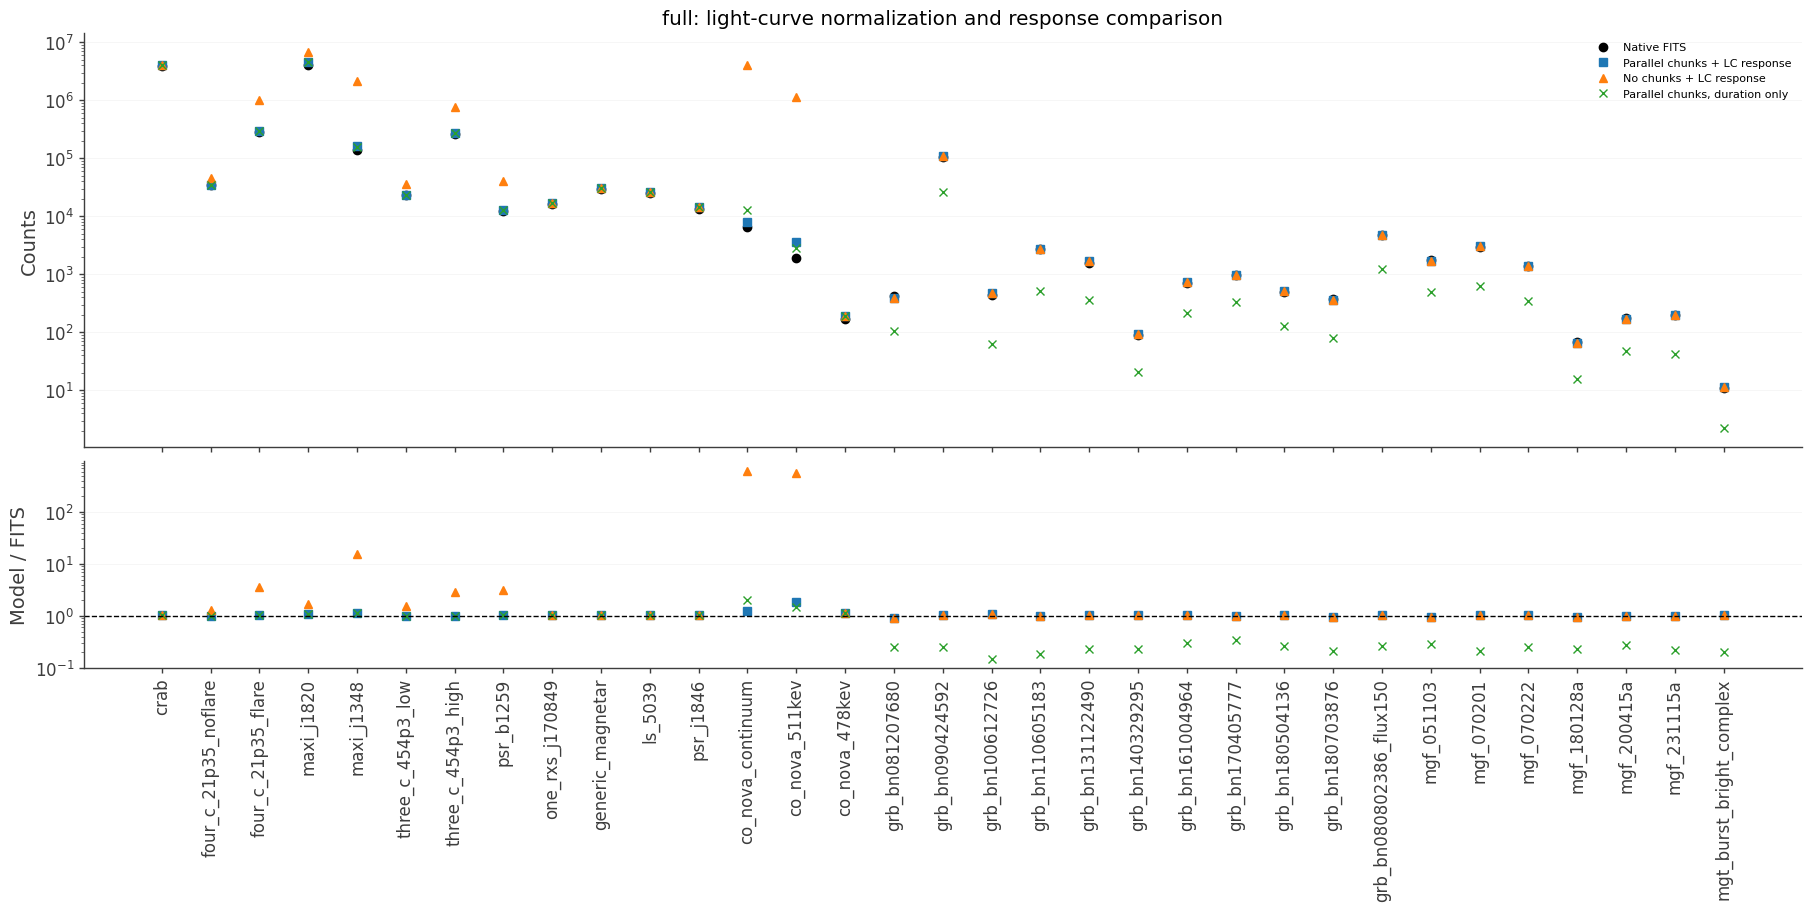

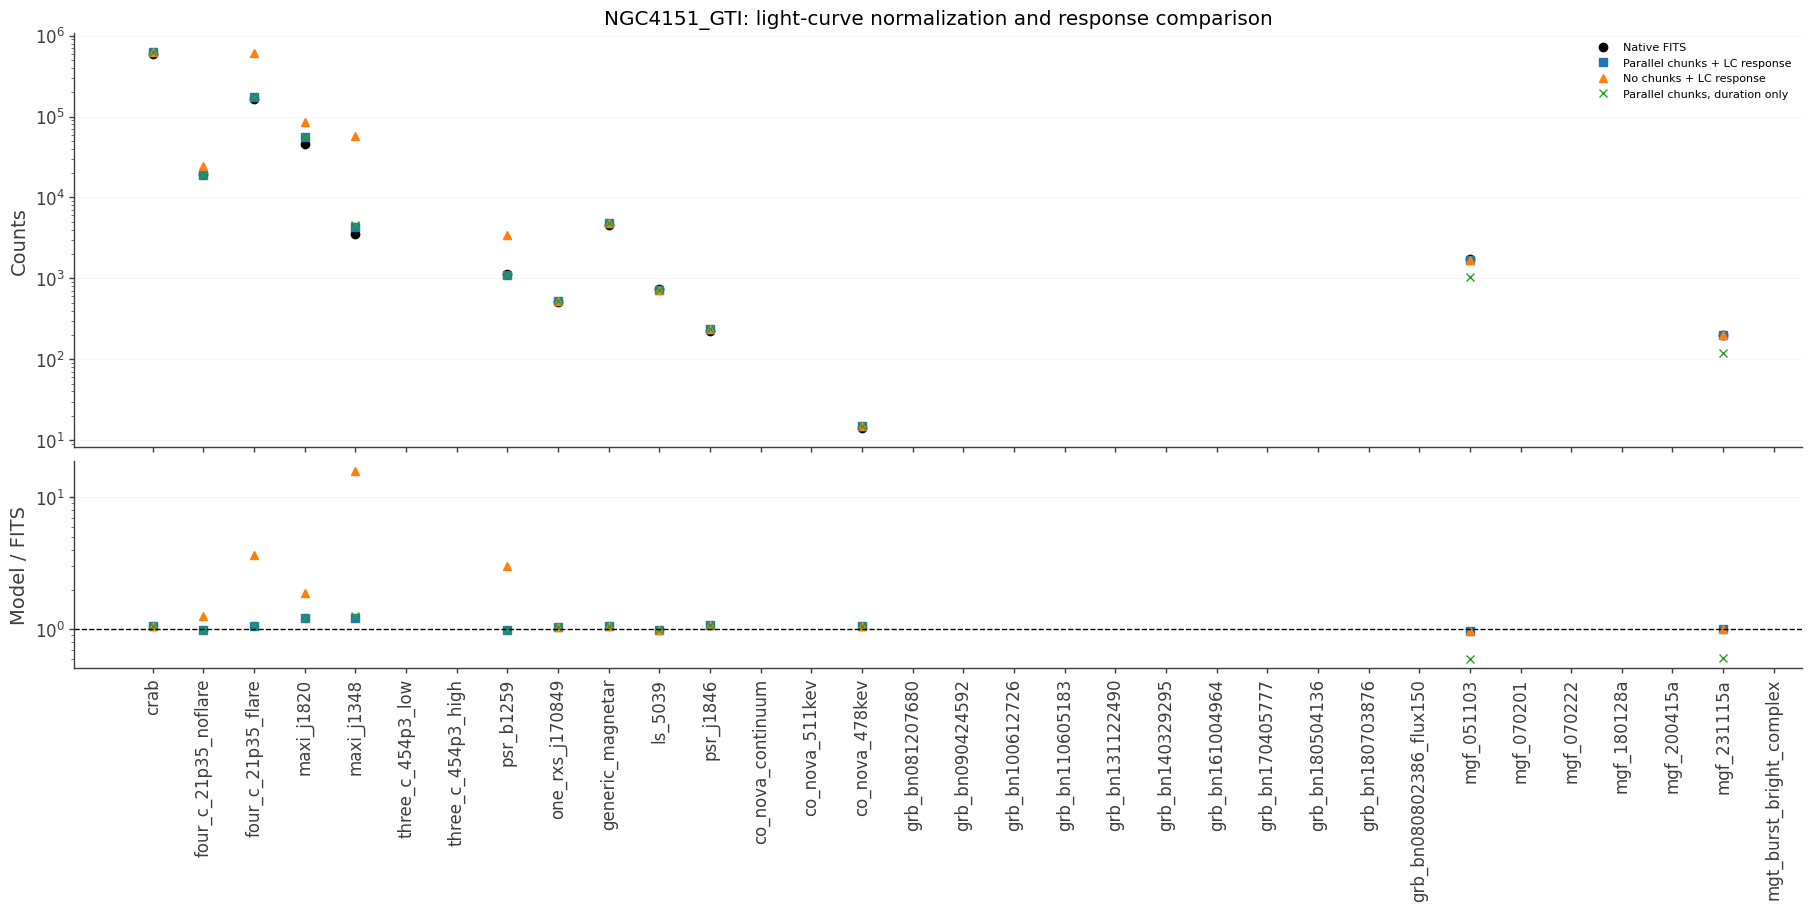

In [37]:
variable_sources = [key for key, blocks in injection_blocks.items()
                    if any(block.get("Lightcurve") is not None for block in blocks)]
for selection in selections:
    table = count_comparison.query("selection == @selection").set_index("source").loc[variable_sources]
    x = np.arange(len(table))
    fig, (ax_counts, ax_ratio) = plt.subplots(2, 1, figsize=(18, 9), sharex=True,
                                            constrained_layout=True,
                                            gridspec_kw={"height_ratios": [2, 1]})
    fig.patch.set_facecolor("white")
    for column, label, color, marker in [
        ("FITS counts", "Native FITS", "black", "o"),
        ("parallel-chunk LC-response counts", "Parallel chunks + LC response", "tab:blue", "s"),
        ("no-chunk LC-response counts", "No chunks + LC response", "tab:orange", "^"),
        ("duration-only folded counts", "Parallel chunks, duration only", "tab:green", "x"),
    ]:
        y = table[column].to_numpy(float)
        ax_counts.plot(x, np.where(y > 1e-20, y, np.nan), marker=marker, ls="none", color=color, label=label)
        if column != "FITS counts":
            observed = table["FITS counts"].to_numpy(float)
            ratio = np.divide(y, observed, out=np.full_like(y, np.nan), where=observed > 0)
            ax_ratio.plot(x, np.where((ratio > 0) & (y > 1e-20), ratio, np.nan), marker=marker, ls="none", color=color)
    ax_counts.set_yscale("log")
    ax_ratio.set_yscale("log")
    ax_ratio.axhline(1., color="black", ls="--", lw=1)
    ax_counts.set_ylabel("Counts")
    ax_ratio.set_ylabel("Model / FITS")
    ax_ratio.set_xticks(x, table.index, rotation=90)
    ax_counts.set_title(f"{selection}: light-curve normalization and response comparison")
    ax_counts.legend(frameon=False)
    for ax in (ax_counts, ax_ratio):
        ax.set_facecolor("white")
        ax.grid(axis="y", which="major", alpha=.2)
    plt.show()


## Energy-binned comparisons for representative transient sources

Edit `PLOT_SOURCES` to inspect any catalog entries. These are measured-energy
counts after response folding, not incident flux curves. Empty GTI panels are
explicitly labeled. Figures are displayed only, not saved automatically.


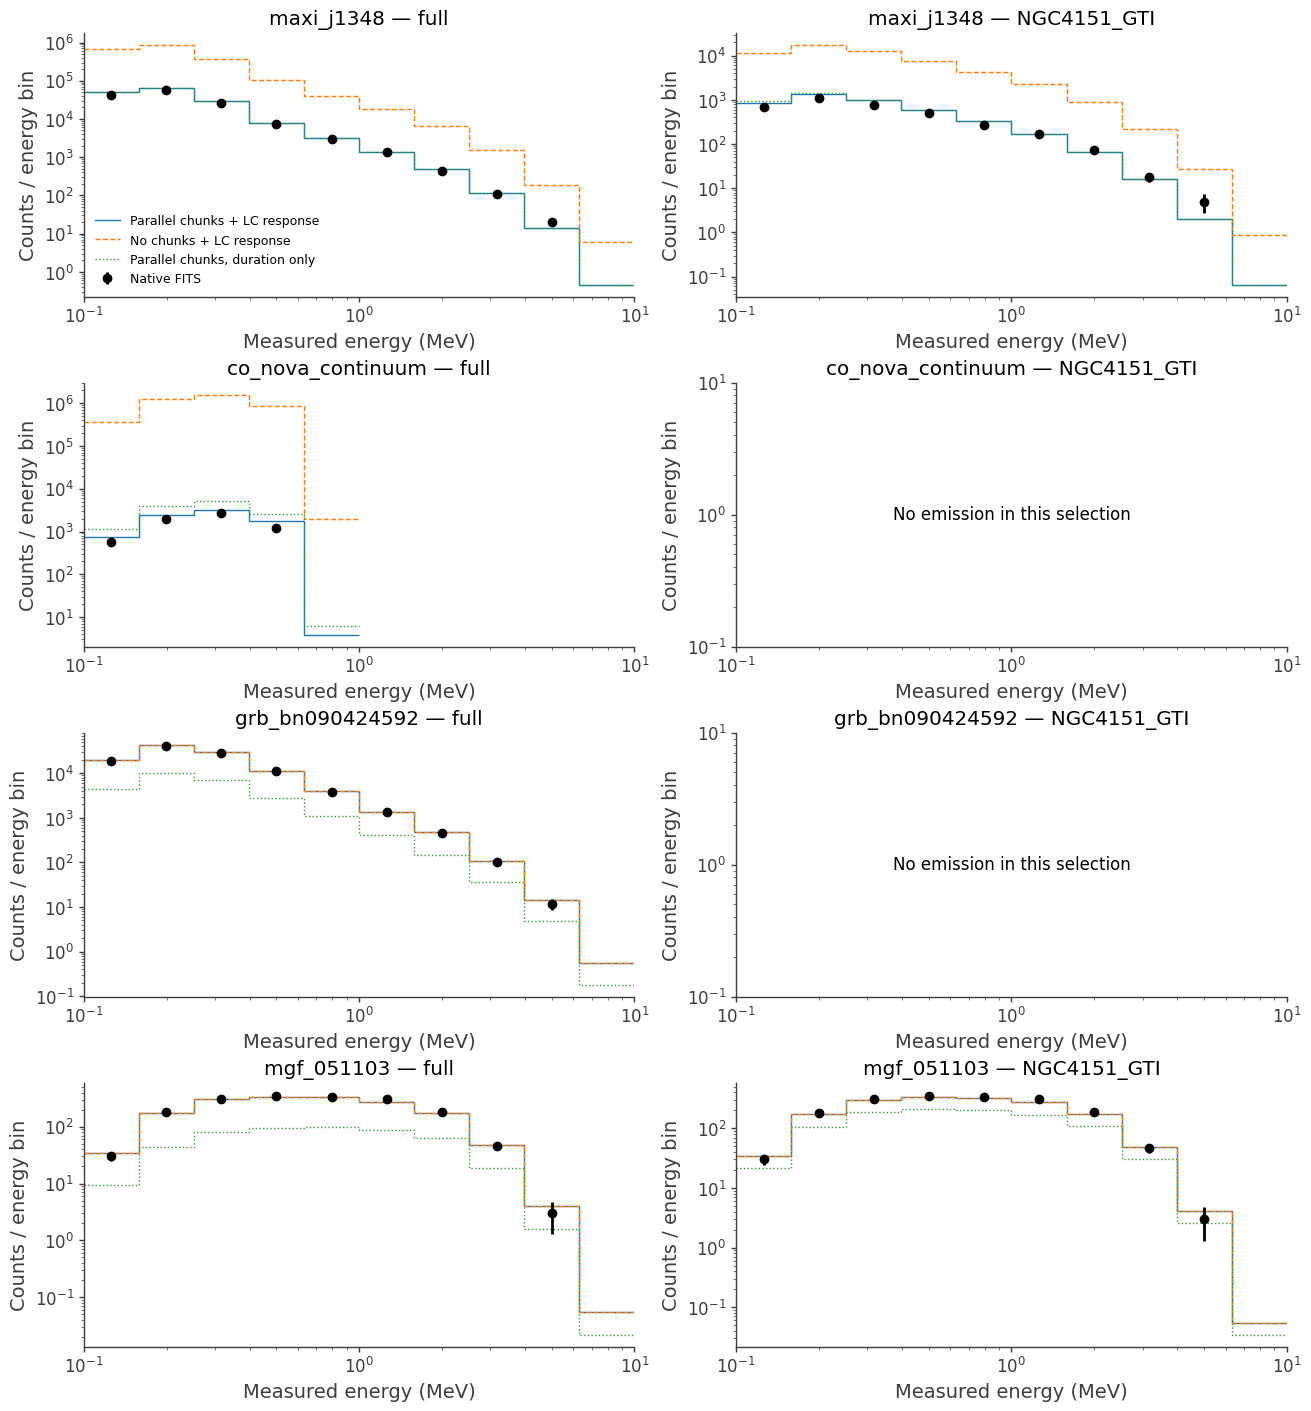

In [38]:
PLOT_SOURCES = ["maxi_j1348", "co_nova_continuum", "grb_bn090424592", "mgf_051103"]
missing = set(PLOT_SOURCES) - set(simulation_units)
if missing:
    raise ValueError(f"Unknown plot sources: {sorted(missing)}")
edges = measurement_axes["Em"].edges.to_value(u.keV) / 1000.
centers = np.sqrt(edges[:-1] * edges[1:])
fig, axes = plt.subplots(len(PLOT_SOURCES), len(selections),
                         figsize=(13, 3.5 * len(PLOT_SOURCES)), squeeze=False,
                         constrained_layout=True)
fig.patch.set_facecolor("white")
for row, key in enumerate(PLOT_SOURCES):
    for col, selection in enumerate(selections):
        ax = axes[row, col]
        spectra = comparison_spectra[selection, key]
        observed = spectra["FITS"]
        ax.errorbar(centers, np.where(observed > 0, observed, np.nan),
                    yerr=np.sqrt(observed), fmt="o", color="black", label="Native FITS")
        for label, color, ls in [
            ("Parallel chunks + LC response", "tab:blue", "-"),
            ("No chunks + LC response", "tab:orange", "--"),
            ("Parallel chunks, duration only", "tab:green", ":"),
        ]:
            values = spectra[label]
            ax.stairs(np.where(values > 1e-20, values, np.nan), edges,
                      color=color, ls=ls, label=label, baseline=None)
        if not any(np.any(values > 1e-20) for values in spectra.values()):
            ax.text(.5, .5, "No emission in this selection", transform=ax.transAxes,
                    ha="center", va="center")
            ax.set_ylim(.1, 10.)
        ax.set_xscale("log")
        ax.set_xlim(edges[0], edges[-1])
        ax.set_yscale("log")
        ax.set_facecolor("white")
        ax.set_title(f"{key} — {selection}")
        ax.set_xlabel("Measured energy (MeV)")
        ax.set_ylabel("Counts / energy bin")
        if row == 0 and col == 0:
            ax.legend(fontsize=9, frameon=False)
plt.show()
